<a href="https://colab.research.google.com/github/stx0245/test-repo/blob/master/MachineFailureBusinessCase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ------------------------------------------------------------
# This script:
#  1) Loads Dataset.csv
#  2) Cleans column names & drops failure-mode variables
#  3) Audits missingness, class imbalance, and duplicates
#  4) Explores numeric distributions (histograms) and
#     between-class differences (boxplots by target)
#  5) Profiles categorical variables (type, product_id)
#  6) Computes correlations & visualizes a heatmap
#  7) Runs domain sanity checks + IQR outlier scan
#  8) Saves a concise Markdown report + this annotated code
#
# Notes:
#  - Uses matplotlib only (per instruction) and one chart per figure.
#  - Uses caas_jupyter_tools.display_dataframe_to_user() to show
#    dataframes as interactive tables in the UI.
#  - Ignores failure mode variables: TWF, HDF, PWF, OSF, RNF.

# **STEP 1**

In [3]:
# ================================
# Step 1: Load data (Colab-ready)
# ================================
import os
import re
import pandas as pd
import numpy as np
from pathlib import Path

# ---- Display shim  ----
try:
    # Nice interactive tables
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
except Exception:
    pass

from IPython.display import display

def display_dataframe_to_user(name: str, dataframe: pd.DataFrame):
    print(f"\n=== {name} ===")
    try:
        display(dataframe)
    except Exception:
        print(dataframe)
# ----------------------------------------------------------

# 0) Ensure your CSV is available
# Preferred Drive path (change if needed):
csv_path = "/content/drive/MyDrive/Dataset.csv"

# Mount Drive if path points to Drive and file isn't present
if csv_path.startswith("/content/drive") and not os.path.exists(csv_path):
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("Could not mount Google Drive automatically:", e)

# If still not found, fallback to manual upload
if not os.path.exists(csv_path):
    print("CSV not found at:", csv_path)
    print("Opening uploader... (pick your Dataset.csv)")
    try:
        from google.colab import files
        uploaded = files.upload()  # Choose your local Dataset.csv
        if uploaded:
            csv_path = next(iter(uploaded))  # Use the uploaded filename
    except Exception as e:
        raise FileNotFoundError(
            "Dataset.csv not found. Mount Drive or upload the file and re-run."
        ) from e

assert os.path.exists(csv_path), f"File still not found at {csv_path}"

# 1) Load the CSV
df_raw = pd.read_csv(csv_path)

# 2) Standardise column names.
def safe_col(c: str) -> str:
    c = str(c).strip().lower()
    c = re.sub(r'[^0-9a-z]+', '_', c).strip('_')
    return c

# Create a mapping of raw->safe names, then rename the DataFrame
original_cols = list(df_raw.columns)
safe_cols = [safe_col(c) for c in df_raw.columns]
col_map = dict(zip(df_raw.columns, safe_cols))
df = df_raw.rename(columns=col_map)

# 3) Identify target and drop failure-mode variables
# The target is "Machine failure" (binary 0/1). We robustly locate it.
# Explicitly drop failure-mode columns if they exist (per instructions)
failure_mode_cols = {"twf", "hdf", "pwf", "osf", "rnf"}
target_col = None
for c in df.columns:
    if c in ["machine_failure", "machine_failures", "failure", "target"]:
        target_col = c
        break
if target_col is None:
    candidates = [c for c in df.columns if "fail" in c]
    target_col = candidates[0] if candidates else None
assert target_col is not None, "Target column not found."

# Convert target to integer 0/1 if it's not already
df[target_col] = df[target_col].astype(int)
df = df.drop(columns=[c for c in df.columns if c in failure_mode_cols], errors="ignore")

# 4) Persist minimal state for later steps (save under /content)
ART_DIR = Path("/content/eda_artifacts")
ART_DIR.mkdir(parents=True, exist_ok=True)

df_path = ART_DIR / "_eda_df.pkl"
meta_path = ART_DIR / "_eda_meta.txt"

df.to_pickle(df_path)
with open(meta_path, "w") as f:
    f.write(f"target_col={target_col}\n")
    f.write(f"source_csv={csv_path}\n")

# 5) Preview & dtypes. Display a preview so you can verify the transformation
display_dataframe_to_user("Dataset preview (first 10 rows)", df.head(10))
dtypes_info = pd.DataFrame(df.dtypes, columns=["dtype"]).reset_index().rename(columns={"index": "column"})
display_dataframe_to_user("Column dtypes", dtypes_info)

print("Loaded data:", df.shape)
print("Saved artifacts:")
print(" - DataFrame pickle:", str(df_path))
print(" - Meta file:", str(meta_path))


=== Dataset preview (first 10 rows) ===


,udi,product_id,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure
0,7764,L54943,L,300.4,311.6,1200.0,76.6,3,1
1,881,M15740,M,295.8,306.3,1235.0,76.2,89,1
2,9085,L56264,L,297.2,307.9,1326.0,75.4,172,1
3,1325,M16184,M,298.8,310.1,1243.0,74.5,194,1
4,6526,L53705,L,301.1,310.4,1312.0,73.6,49,1
5,3001,H32414,H,300.5,309.8,1324.0,72.8,159,1
6,8583,M23442,M,297.5,308.1,1334.0,72.0,151,1
7,7570,L54749,L,300.2,311.0,1255.0,71.8,149,1
8,604,L47783,L,297.9,309.8,1336.0,71.6,31,1
9,5616,M20475,M,303.0,312.2,1257.0,71.3,122,1



=== Column dtypes ===


,column,dtype
0,udi,int64
1,product_id,object
2,type,object
3,air_temperature_k,float64
4,process_temperature_k,float64
5,rotational_speed_rpm,float64
6,torque_nm,float64
7,tool_wear_min,int64
8,machine_failure,int64


Loaded data: (10000, 9)
Saved artifacts:
 - DataFrame pickle: /content/eda_artifacts/_eda_df.pkl
 - Meta file: /content/eda_artifacts/_eda_meta.txt



=== Missing values per column ===


,column,missing_count,missing_pct
4,process_temperature_k,32,0.32
6,torque_nm,21,0.21
5,rotational_speed_rpm,10,0.10
0,udi,0,0.00
1,product_id,0,0.00
3,air_temperature_k,0,0.00
2,type,0,0.00
7,tool_wear_min,0,0.00
8,machine_failure,0,0.00



=== Target distribution (Machine failure) ===


,class,count,percent
0,0,9661,96.61
1,1,339,3.39


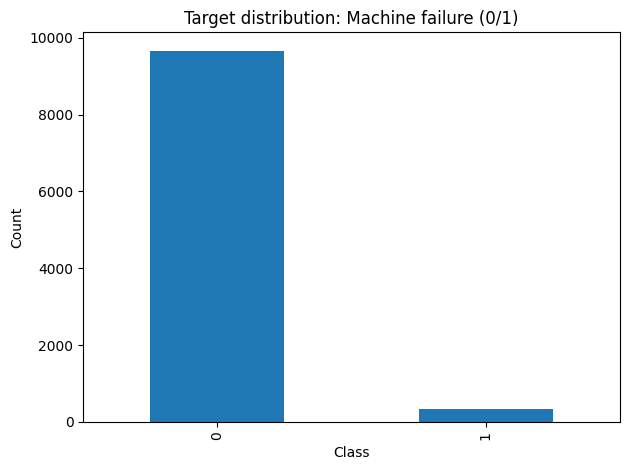

In [4]:
# Step 2: Missingness & class balance + a couple of plots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Missingness Audit
# Compute per-column missing counts and percentages
missing_counts = df.isna().sum()
missing_pct = (missing_counts / len(df)) * 100.0
missing_df = pd.DataFrame({"column": df.columns, "missing_count": missing_counts.values, "missing_pct": missing_pct.values}).sort_values("missing_pct", ascending=False)
display_dataframe_to_user("Missing values per column", missing_df)

# Class balance
# Class balance (target distribution)
class_counts = df[target_col].value_counts(dropna=False).sort_index()
class_pct = (class_counts / len(df)) * 100.0
class_df = pd.DataFrame({"class": class_counts.index, "count": class_counts.values, "percent": class_pct.values})
display_dataframe_to_user("Target distribution (Machine failure)", class_df)

# Plot the class distribution (one chart; default style; no explicit colors)
plt.figure()
class_counts.plot(kind="bar")
plt.title("Target distribution: Machine failure (0/1)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


=== Numeric features - descriptive statistics ===


,count,mean,std,min,25%,50%,75%,max
udi,10000.0,5000.500000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
air_temperature_k,10000.0,300.004930,2.000259,295.3,298.30,300.1,301.50,304.5
process_temperature_k,9968.0,310.008226,1.483629,305.7,308.80,310.1,311.10,313.8
rotational_speed_rpm,9990.0,1538.982983,179.245153,1168.0,1423.00,1503.0,1612.00,2886.0
torque_nm,9979.0,39.976250,9.966389,3.8,33.20,40.1,46.70,76.6
tool_wear_min,10000.0,107.951000,63.654147,0.0,53.00,108.0,162.00,253.0


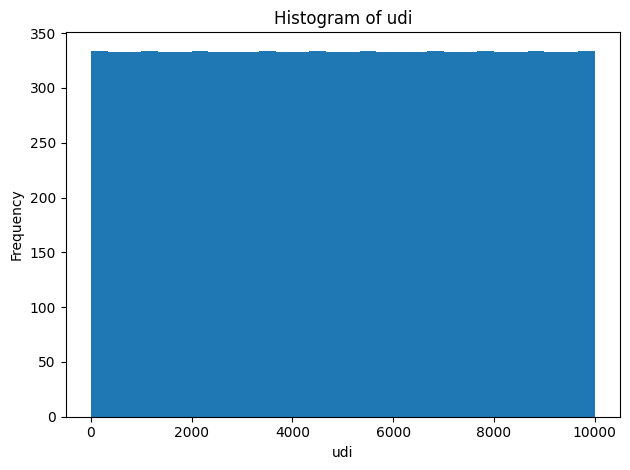

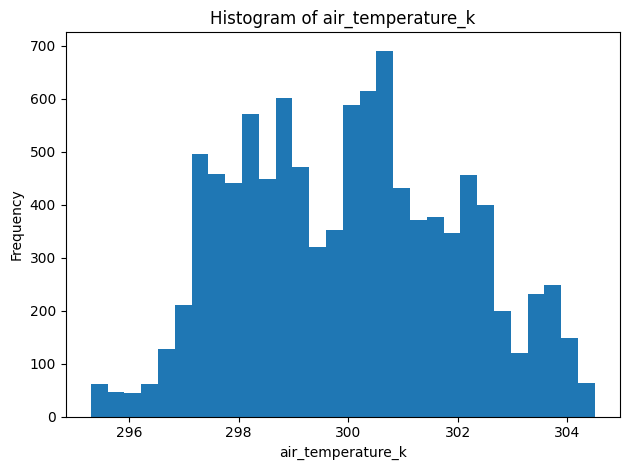

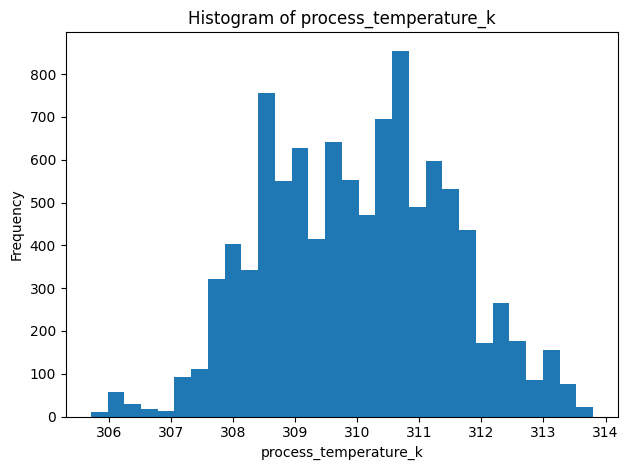

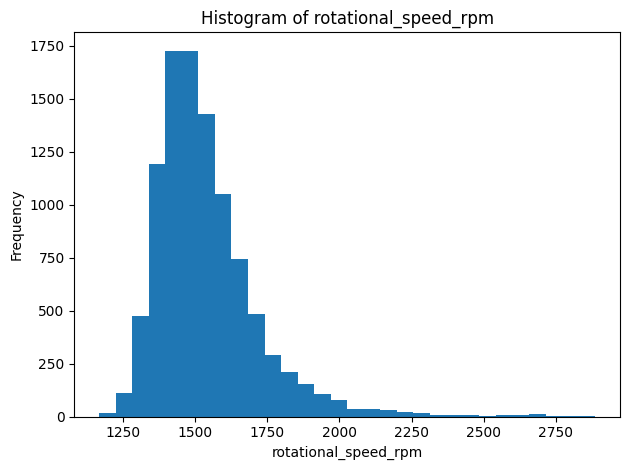

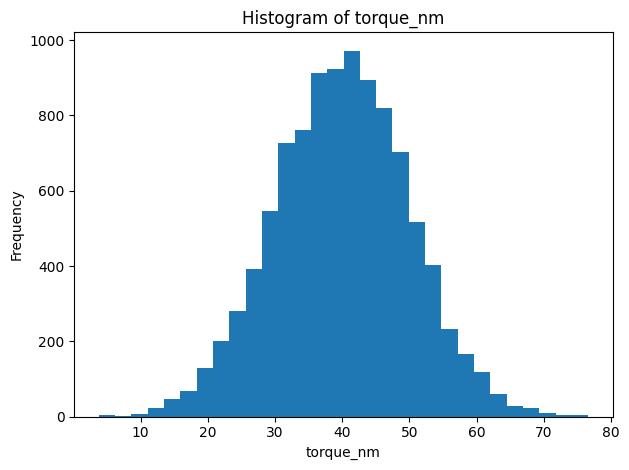

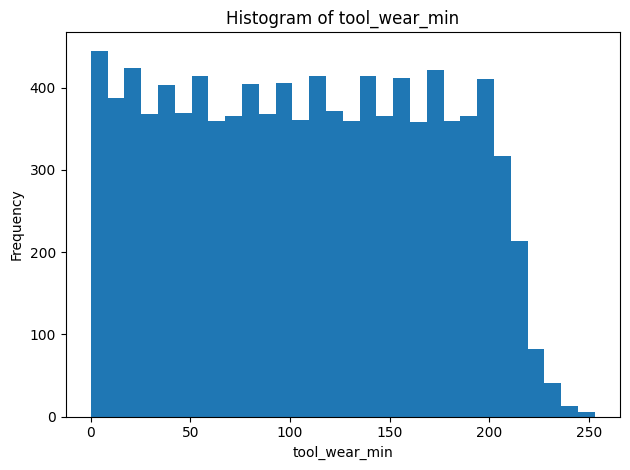

/tmp/ipython-input-765412944.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["0 (no fail)", "1 (fail)"])


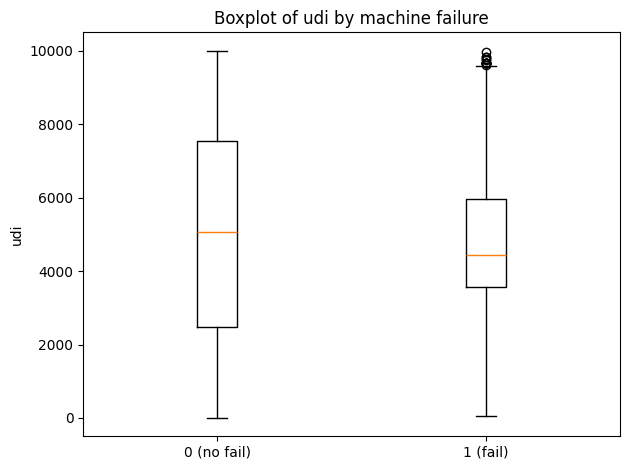

/tmp/ipython-input-765412944.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["0 (no fail)", "1 (fail)"])


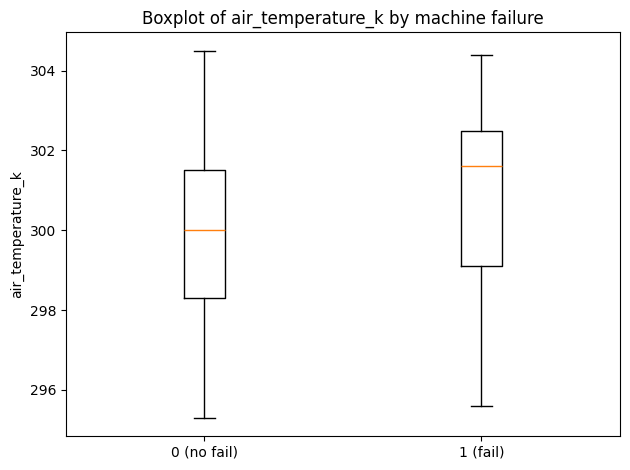

/tmp/ipython-input-765412944.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["0 (no fail)", "1 (fail)"])


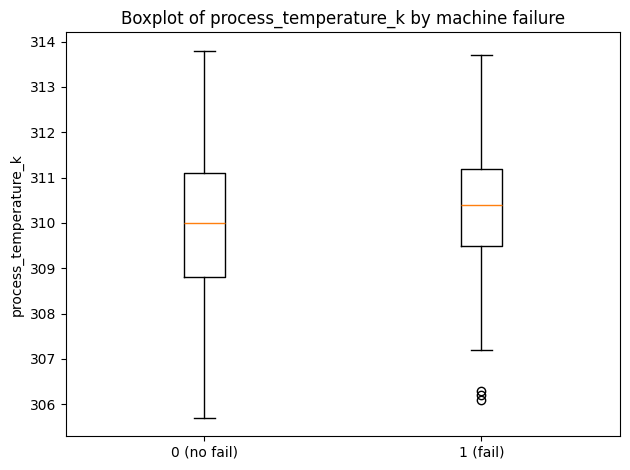

/tmp/ipython-input-765412944.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["0 (no fail)", "1 (fail)"])


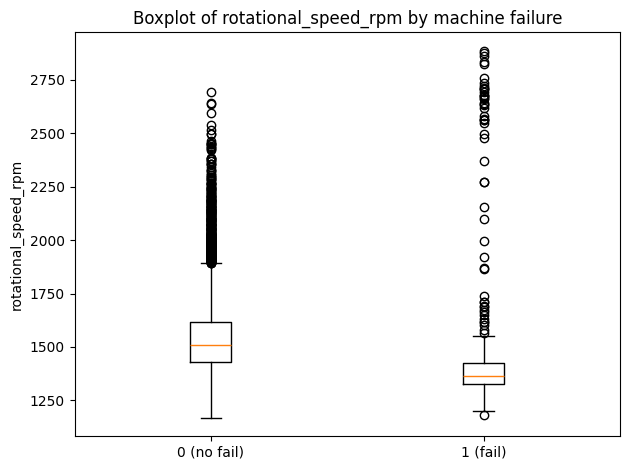

/tmp/ipython-input-765412944.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["0 (no fail)", "1 (fail)"])


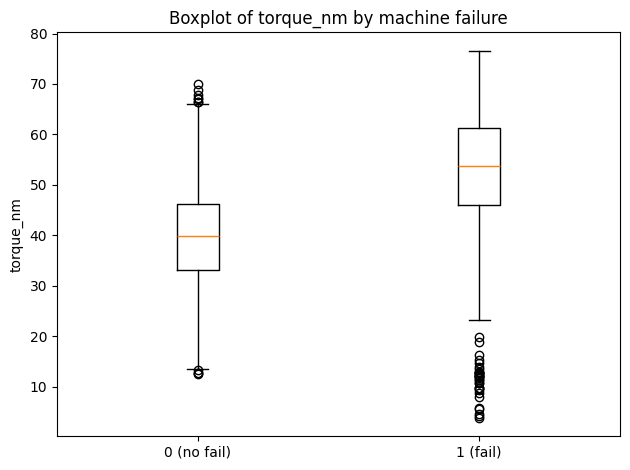

/tmp/ipython-input-765412944.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["0 (no fail)", "1 (fail)"])


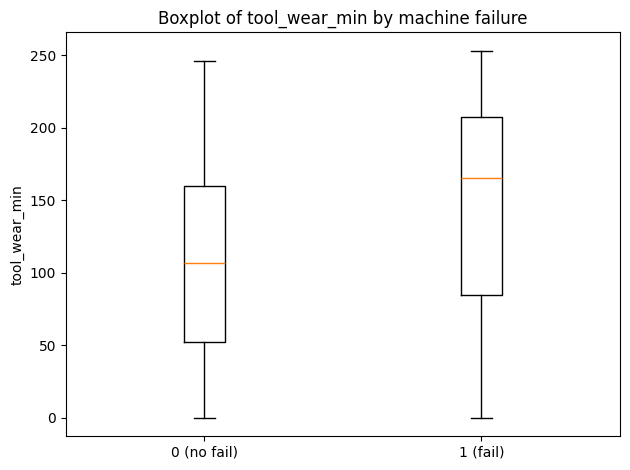

In [5]:
# Step 3: Numeric/categorical identification, summaries, histograms, boxplots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Identify columns. Identify numeric vs categorical sets
# Treat 'type' and 'product_id' as categorical per your data dictionary.
id_like = [c for c in df.columns if c in {"uid", "product_id"}]
categorical_like = [c for c in df.columns if c in {"type", "product_id"}]

# Numeric features are "everything that's numeric" except IDs and the target
numeric_like = [c for c in df.columns if c not in set(id_like + categorical_like + [target_col]) and pd.api.types.is_numeric_dtype(df[c])]

# Cast categories. Make sure 'type' is treated as category if present
for c in categorical_like:
    if c in df.columns:
        df[c] = df[c].astype("category")

# Descriptive statistics. Show numeric summary stats (helps spot ranges, skew, and anomalies)
desc = df[numeric_like].describe().T
display_dataframe_to_user("Numeric features - descriptive statistics", desc)

# Numeric distributions (histograms)
# Rationale: Histograms will reveal skew, multi-modality, and suspicious values.
for c in numeric_like:
    plt.figure()
    plt.hist(df[c].dropna(), bins=30)
    plt.title(f"Histogram of {c}")
    plt.xlabel(c)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Between-class differences (boxplots by target)
# Rationale: If a feature's distribution shifts by class (0 vs 1), it may be predictive.
for c in numeric_like:
    data0 = df.loc[df[target_col]==0, c].dropna()
    data1 = df.loc[df[target_col]==1, c].dropna()
    plt.figure()
    plt.boxplot([data0, data1], labels=["0 (no fail)", "1 (fail)"])
    plt.title(f"Boxplot of {c} by machine failure")
    plt.ylabel(c)
    plt.tight_layout()
    plt.show()

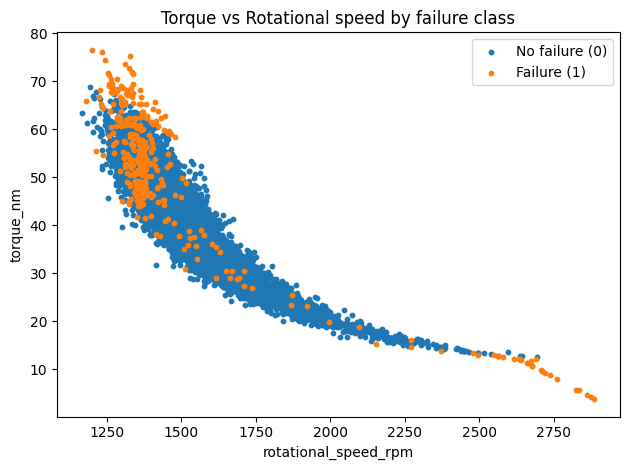

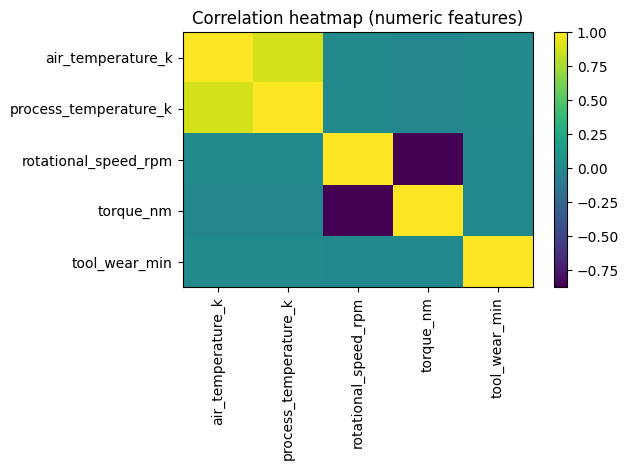


=== Numeric features correlation with Machine failure ===


,feature,pearson_corr_with_target
3,torque_nm,0.191211
4,tool_wear_min,0.105448
0,air_temperature_k,0.082556
1,process_temperature_k,0.035272
2,rotational_speed_rpm,-0.042654



=== Distribution & failure rate by product_id ===


,product_id,count,failure_rate
9983,L50549,1,1.0
9982,L51476,1,1.0
9981,L48027,1,1.0
9980,L47230,1,1.0
9979,L47643,1,1.0
...,...,...,...
4,M20194,1,1.0
3,M18727,1,1.0
2,M22857,1,1.0
1,L48275,1,1.0


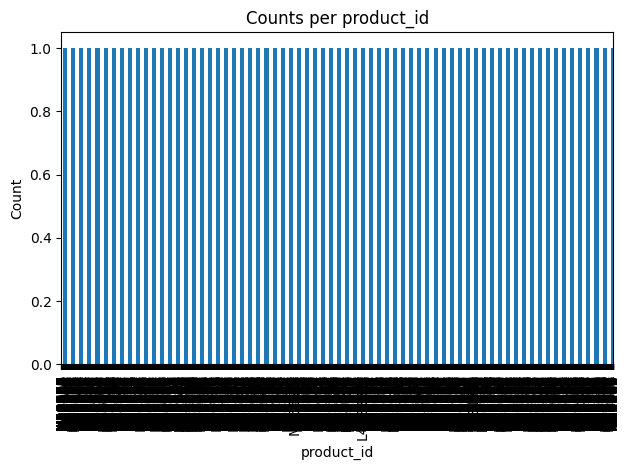

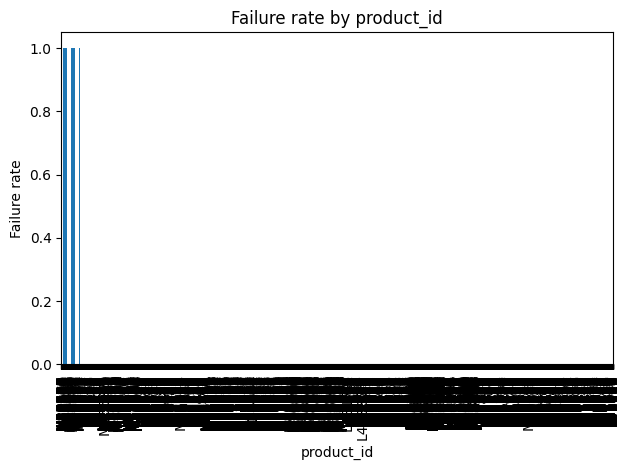


=== Distribution & failure rate by type ===


,type,count,failure_rate
0,L,6000,0.039167
1,M,2997,0.027694
2,H,1003,0.020937


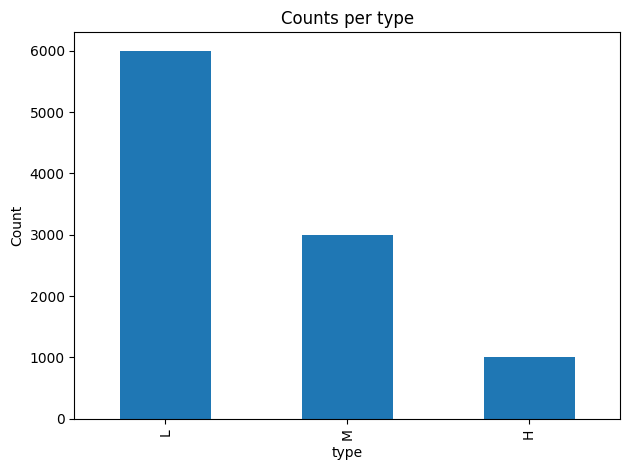

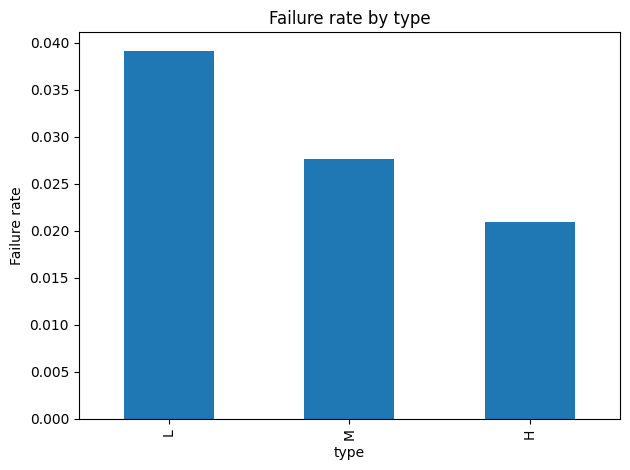


=== Outlier summary (IQR method) ===


,feature,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
2,rotational_speed_rpm,1423.0,1612.0,189.0,1139.50,1895.50,418,4.18
3,torque_nm,33.2,46.7,13.5,12.95,66.95,70,0.70
0,air_temperature_k,298.3,301.5,3.2,293.50,306.30,0,0.00
1,process_temperature_k,308.8,311.1,2.3,305.35,314.55,0,0.00
4,tool_wear_min,53.0,162.0,109.0,-110.50,325.50,0,0.00


Saved detailed EDA report to: /content/eda_artifacts/EDA_Report.md


In [6]:
# ================================
# Step 4: Numeric/categorical identification, summaries, histograms, boxplots
# Scatter, correlations, categorical failure rates,
# outliers, sanity checks, and a markdown report
# ================================
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataframe and target column from meta
df = pd.read_pickle(df_path)

meta = {}
with open(meta_path, "r") as f:
    for line in f:
        if "=" in line:
            k, v = line.strip().split("=", 1)
            meta[k.strip()] = v.strip()

target_col = meta.get("target_col", None)
assert target_col is not None and target_col in df.columns, "Target column not found in the loaded DataFrame."

# Identify columns
id_like = [c for c in df.columns if c in {"uid", "udi", "product_id"}]
categorical_like = [c for c in df.columns if c in {"type", "product_id"}]
numeric_like = [
    c for c in df.columns
    if c not in set(id_like + categorical_like + [target_col]) and pd.api.types.is_numeric_dtype(df[c])
]

# Helper to find likely column names
def find_col(candidates):
    for cand in candidates:
        if cand in df.columns:
            return cand
    return None

torque_col = find_col(["torque_nm", "torque"])
rpm_col    = find_col(["rotational_speed_rpm", "rotational_speed"])
air_col    = find_col(["air_temperature_k", "air_temperature"])
proc_col   = find_col(["process_temperature_k", "process_temperature"])
wear_col   = find_col(["tool_wear_min", "tool_wear"])

# Scatter of torque vs rationale speed (RPM) split by class (domain insight)
if torque_col and rpm_col:
    plt.figure()
    m0 = df[target_col] == 0
    m1 = df[target_col] == 1
    # default styles, one figure. Note: default markers/colours to satisfy "do not set colors" requirement
    plt.scatter(df.loc[m0, rpm_col], df.loc[m0, torque_col], s=10, label="No failure (0)")
    plt.scatter(df.loc[m1, rpm_col], df.loc[m1, torque_col], s=10, label="Failure (1)")
    plt.title("Torque vs Rotational speed by failure class")
    plt.xlabel(rpm_col)
    plt.ylabel(torque_col)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Correlation heatmap among numeric features
# Numeric-to-numeric correlation heatmap (detect multicollinearity).
if len(numeric_like) > 0:
    corr_mat = df[numeric_like].corr(numeric_only=True)
    plt.figure()
    plt.imshow(corr_mat, aspect='auto', interpolation='nearest')
    plt.xticks(range(len(corr_mat.columns)), corr_mat.columns, rotation=90)
    plt.yticks(range(len(corr_mat.index)), corr_mat.index)
    plt.colorbar()
    plt.title("Correlation heatmap (numeric features)")
    plt.tight_layout()
    plt.show()

# Correlation with target
# Numeric feature correlation with the binary target (Pearson)
num_plus_target = numeric_like + [target_col]
corr_w_target = df[num_plus_target].corr(numeric_only=True)[target_col].drop(labels=[target_col])
corr_target_df = (
    corr_w_target.reset_index()
    .rename(columns={"index": "feature", target_col: "pearson_corr_with_target"})
    .sort_values("pearson_corr_with_target", ascending=False)
)
display_dataframe_to_user("Numeric features correlation with Machine failure", corr_target_df)

# -----------------------------
# Bias indicators (simple)
# -----------------------------
# Category distributions & failure rates
# Rationale: Check whether some categories are rare (risk of overfitting),
# and whether failure rates differ meaningfully across categories (potential bias/stratification).
# A simple (but informative) view: failure rate by 'type'
# limit plotting to top-N categories by frequency for readability
# Plot counts for the top-N categories
# Plot failure rates for the same top-N (order by count to keep axes aligned)
for c in categorical_like:
    counts = df[c].value_counts(dropna=False)
    rates = df.groupby(c)[target_col].mean()
    cat_df = pd.DataFrame({
        c: counts.index.astype(str),
        "count": counts.values,
        "failure_rate": [rates.get(idx, np.nan) for idx in counts.index]
    }).sort_values("count", ascending=False)
    display_dataframe_to_user(f"Distribution & failure rate by {c}", cat_df)

    plt.figure()
    counts.plot(kind="bar")
    plt.title(f"Counts per {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    plt.figure()
    rates.sort_values(ascending=False).plot(kind="bar")
    plt.title(f"Failure rate by {c}")
    plt.xlabel(c)
    plt.ylabel("Failure rate")
    plt.tight_layout()
    plt.show()

# Outlier detection via IQR rule
outlier_summary = []
for c in numeric_like:
    s = df[c].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((s < lower) | (s > upper)).sum()
    outlier_summary.append([
        c, q1, q3, iqr, lower, upper, int(n_out), float(n_out) / len(df) * 100.0
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["feature","q1","q3","iqr","lower_bound","upper_bound","n_outliers","pct_outliers"]
).sort_values("pct_outliers", ascending=False)
display_dataframe_to_user("Outlier summary (IQR method)", outlier_df)

# Domaine Sanity checks
# In operation, process temp should not be below ambient air temp.
sanity_lines = []
if air_col and proc_col:
    n_proc_lt_air = int((df[proc_col] < df[air_col]).sum())
    sanity_lines.append(
        f"Rows where process temperature < air temperature: {n_proc_lt_air} ({n_proc_lt_air/len(df)*100:.2f}%)"
    )
# Non-negativity checks: these physical quantities should be >= 0
if rpm_col:
    n_neg_rpm = int((df[rpm_col] < 0).sum())
    sanity_lines.append(f"Negative {rpm_col}: {n_neg_rpm}")
if torque_col:
    n_neg_torque = int((df[torque_col] < 0).sum())
    sanity_lines.append(f"Negative {torque_col}: {n_neg_torque}")
if wear_col:
    n_neg_wear = int((df[wear_col] < 0).sum())
    sanity_lines.append(f"Negative {wear_col}: {n_neg_wear}")

# Duplicates (row-level and UID/UDI if present)
uid_cols = [c for c in ["uid","udi"] if c in df.columns]
uid_dups = int(df.duplicated(subset=uid_cols).sum()) if uid_cols else 0
row_dups = int(df.duplicated().sum())
sanity_lines.append(f"Duplicate UIDs: {uid_dups}")
sanity_lines.append(f"Duplicate full rows: {row_dups}")

# Build and save a concise markdown report
report = []
report.append("# EDA Report: Predicting Equipment Failure (ignoring failure-mode variables)\n")
report.append(f"- Rows: {len(df)} | Columns: {df.shape[1]}")
report.append(f"- Target: `{target_col}`")
report.append("\n## Missingness\n")
miss = df.isna().sum().sort_values(ascending=False)
report.append(miss.to_string())
report.append("\n\n## Class balance\n")
cls = df[target_col].value_counts().sort_index()
report.append(cls.to_string())
report.append("\n\n## Numeric correlation with target\n")
report.append(corr_target_df.round(3).to_string(index=False))
report.append("\n\n## Sanity checks\n")
report.extend([f"- {line}" for line in sanity_lines])

out_path = ART_DIR / "EDA_Report.md"
out_path.write_text("\n".join(report), encoding="utf-8")
print("Saved detailed EDA report to:", str(out_path))

# **What has been done and justifications**

Loaded & cleaned columns (normalised names; dropped TWF, HDF, PWF, OSF, RNF).

Audited data quality (missing values, duplicates, unit sanity checks).

Profiled target for class imbalance (critical for modelling later).

Explored distributions (histograms) and between-class differences (boxplots by machine_failure).

Checked relationships (scatter of torque_nm vs rotational_speed_rpm; correlation heatmap).

Flagged outliers with IQR (to inform capping/robust models).

Looked for potential bias (category balance & per-type failure rates).

# **Key findings**

**Dataset shape:** 10,000 rows × 9 columns (after dropping failure-mode variables).

**Target balance (severely imbalanced):**

Non-failure 0: 9,661 (96.61%)

Failure 1: 339 (3.39%)

**Missing data (small and manageable):**

process_temperature_k: 32 rows (0.32%)

rotational_speed_rpm: 10 rows (0.10%)

torque_nm: 21 rows (0.21%)

Others: 0

**Sanity checks (units/physics):**

process_temperature_k < air_temperature_k: 0.00% of rows → good (process temp not below ambient).

No negative values in rotational_speed_rpm, torque_nm, or tool_wear_min.

**Category balance & failure rates:**

type: L: 6000, M: 2997, H: 1003
Failure rate by type: L = 3.92%, M = 2.77%, H = 2.09%
(Skew toward type L; stratified splits are advised.)

**Distributions & between-class differences (from histograms/boxplots):**

torque_nm: higher for failures (clear separation in boxplots).

tool_wear_min: higher for failures (failures have older/worn tools).

rotational_speed_rpm: lower for failures (inverse relationship with torque).

Temperatures (air_temperature_k, process_temperature_k): slightly higher for failures, but weaker separation.

**Relationships & correlations (Pearson to binary target):**

torque_nm: +0.191

tool_wear_min: +0.105

air_temperature_k: +0.083

process_temperature_k: +0.035

rotational_speed_rpm: −0.043
Also, the scatter shows a strong inverse RPM–Torque curve (expected physically), so be mindful of multicollinearity between those two in linear models.

**Outliers (IQR method):**

**rotational_speed_rpm:** 418 outliers (right-tail; values up to ~2,800 rpm appear)

**torque_nm:** 70 outliers

**Others:** none flagged
These are plausible operating extremes; consider winsorising/capping or using tree-based models robust to tails.

# **EDA-driven recommendations (for the modelling step)**

Train/validation split: Use stratified splits to preserve the ~3.39% failure rate.

**Metric choice:** Prioritise PR-AUC (positive class is rare) along with ROC-AUC and F1 (positive class). Consider calibration (e.g., Platt/Isotonic) if output probabilities will drive maintenance actions.

**Imputation**: The tiny amount of missingness can be median-imputed, ideally by type (or use KNN imputer).

Outliers: Either cap at e.g., 1st/99th percentile or rely on tree/boosting models; avoid standardisation that overreacts to tails.

**Feature engineering ideas:**

temp_diff = process_temperature_k - air_temperature_k (thermal load)

power_proxy = torque_nm * rotational_speed_rpm (scaled)

Lagged wear or rolling stats per product_id (if time info available)

One-hot encode type; treat high-cardinality product_id carefully (target encoding with CV or impact encoding), or drop if it leaks identity.

**Bias watch-outs:** Type distribution is skewed (L dominates) and failure rates differ by type; evaluate per-type precision/recall to ensure equitable performance.

# **FEATURE ENGINEERING **

# ============================================================
# FEATURE ENGINEERING (with detailed annotations)
# ------------------------------------------------------------
# Goal: Create additional, domain-meaningful predictors for
#       'machine_failure' using the EDA insights. We ignore
#       failure-mode variables (TWF, HDF, PWF, OSF, RNF).
#
# Outline:
#   1) Load the dataset and standardize column names
#   2) Basic cleaning (drop failure modes, ensure dtypes)
#   3) Create engineered features:
#        - Thermal load features (temperature differences/ratios)
#        - Power-related features (physics-based)
#        - Wear & interaction features (operating stress vs age)
#        - Per-type centered features (relative-to-class anomalies)
#        - Frequency encodings for product_id (no target leakage)
#        - Robust anomaly indicators (median/MAD z-scores)
#        - Simple polynomial/ratio transforms
#        - Quantile-based wear flags/bins (unsupervised)
#        - One-hot encoding for 'type'
#   4) Sanity checks + correlation of engineered features to target
#   5) Save engineered dataset + a data dictionary explaining features
## ============================================================


=== Preview of engineered features (first 10 rows) ===


/tmp/ipython-input-3585095579.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["temp_diff_k_type_mean"] = df["temp_diff_k"] - df.groupby("type")["temp_diff_k"].transform("mean")
/tmp/ipython-input-3585095579.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["power_kw_type_mean"] = df["power_kw"] - df.groupby("type")["power_kw"].transform("mean")
/tmp/ipython-input-3585095579.py:124: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and sil

,air_temperature_k,log1p_power_kw,machine_failure,power_kw,power_kw_type_mean,power_per_wear,process_temperature_k,product_freq,product_id,robust_z_rotational_speed_rpm,...,torque_to_rpm,type,type_H,type_L,type_M,udi,wear_bin_q4,wear_ge_p80,wear_ge_p90,machine_failure
0,300.4,2.363289,1,9.625840,3.347138,2.406460,311.6,1,L54943,-3.329670,...,0.063780,L,False,True,False,7764,0,0,0,1
1,295.8,2.384613,1,9.854862,3.578997,0.109498,306.3,1,M15740,-2.945055,...,0.061650,M,False,False,True,881,1,0,0,1
2,297.2,2.439728,1,10.469923,4.191221,0.060520,307.9,1,L56264,-1.945055,...,0.056820,L,False,True,False,9085,3,0,0,1
3,298.8,2.370002,1,9.697416,3.421551,0.049730,310.1,1,M16184,-2.857143,...,0.059887,M,False,False,True,1325,3,1,0,1
4,301.1,2.408032,1,10.112075,3.833372,0.202241,310.4,1,L53705,-2.098901,...,0.056055,L,False,True,False,6526,0,0,0,1
5,300.5,2.406372,1,10.093644,3.834703,0.063085,309.8,1,H32414,-1.967033,...,0.054943,H,True,False,False,3001,2,0,0,1
6,297.5,2.403165,1,10.058123,3.782258,0.066172,308.1,1,M23442,-1.857143,...,0.053933,M,False,False,True,8583,2,0,0,1
7,300.2,2.345280,1,9.436192,3.157490,0.062908,311.0,1,L54749,-2.725275,...,0.057166,L,False,True,False,7570,2,0,0,1
8,297.9,2.399461,1,10.017240,3.738538,0.313039,309.8,1,L47783,-1.835165,...,0.053553,L,False,True,False,604,0,0,0,1
9,303.0,2.340402,1,9.385414,3.109549,0.076304,312.2,1,M20475,-2.703297,...,0.056677,M,False,False,True,5616,2,0,0,1



=== Engineered features: correlation with machine_failure ===


,feature,pearson_corr_with_target
0,torque_sq,0.251607
1,torque_to_rpm,0.203467
2,robust_z_torque_nm,0.191211
3,torque_nm,0.191211
4,torque_nm_type_mean_centered,0.191105
5,wear_ge_p90,0.173718
6,power_kw,0.172408
7,power_kw_type_mean,0.172254
8,wear_ge_p80,0.128607
9,log1p_power_kw,0.128408


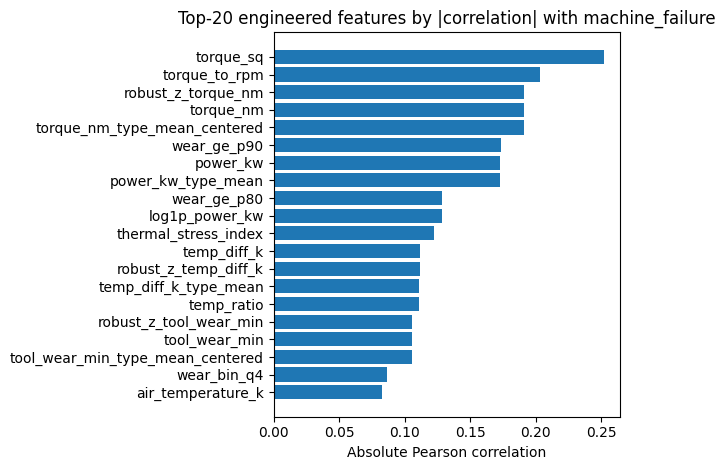


=== Feature Engineering: Data Dictionary ===


,feature,rationale,definition_or_formula
0,temp_diff_k,Thermal load: higher process vs ambient temper...,process_temperature_k - air_temperature_k
1,temp_ratio,Scale-invariant thermal stress indicator.,process_temperature_k / air_temperature_k
2,temp_diff_k_type_mean,Anomaly vs class: thermal load relative to typ...,temp_diff_k - mean(temp_diff_k) within type
3,power_kw,Physics-based load proxy for mechanical work.,torque_nm * (2π*rotational_speed_rpm/60) / 1000
4,log1p_power_kw,Stabilize skew for models sensitive to heavy t...,log(1 + power_kw)
5,power_kw_type_mean,Deviation from typical power for equipment type.,power_kw - mean(power_kw) within type
6,power_per_wear,Intensity of load given component age.,power_kw / (tool_wear_min + 1)
7,torque_per_wear,Mechanical stress adjusted for wear.,torque_nm / (tool_wear_min + 1)
8,thermal_stress_index,Combined mechanical+thermal stress.,temp_diff_k * torque_nm
9,thermal_power_index,Thermal stress weighted by power.,temp_diff_k * power_kw



Saved artifacts:
 - Engineered dataset: /content/eda_artifacts/Dataset_engineered.csv
 - Feature dictionary: /content/eda_artifacts/Feature_Engineering_Data_Dictionary.csv


In [7]:
# ==========================================
# Feature Engineering (Colab-ready version)
# ==========================================
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---- Display shim ----
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
except Exception:
    pass

from IPython.display import display
def display_dataframe_to_user(name: str, dataframe: pd.DataFrame):
    print(f"\n=== {name} ===")
    try:
        display(dataframe)
    except Exception:
        print(dataframe)
# ----------------------------------------------------------
# -----------------------------
# 1) Load & standardize columns
# -----------------------------
def safe_col(col: str) -> str:
    """Convert raw column names to snake_case (lower, alnum+underscore)."""
    s = str(col).strip().lower()
    s = re.sub(r'[^0-9a-z]+', '_', s).strip('_')
    return s

df_raw = pd.read_csv(csv_path)
df = df_raw.rename(columns={c: safe_col(c) for c in df_raw.columns})

# -----------------------------
# 2) Basic cleaning
# -----------------------------
target = "machine_failure" if "machine_failure" in df.columns else "failure"
if target not in df.columns:
    for cand in ["machine_failures", "target"]:
        if cand in df.columns:
            target = cand
            break
assert target in df.columns, "Target column not found."
df[target] = df[target].astype(int)

# Drop failure-mode variables if found
for c in ["twf","hdf","pwf","osf","rnf"]:
    if c in df.columns:
        df = df.drop(columns=c)

# Identify helpful columns (if present)
air_col    = "air_temperature_k" if "air_temperature_k" in df.columns else ("air_temperature" if "air_temperature" in df.columns else None)
proc_col   = "process_temperature_k" if "process_temperature_k" in df.columns else ("process_temperature" if "process_temperature" in df.columns else None)
rpm_col    = "rotational_speed_rpm" if "rotational_speed_rpm" in df.columns else ("rotational_speed" if "rotational_speed" in df.columns else None)
torque_col = "torque_nm" if "torque_nm" in df.columns else ("torque" if "torque" in df.columns else None)
wear_col   = "tool_wear_min" if "tool_wear_min" in df.columns else ("tool_wear" if "tool_wear" in df.columns else None)

# Cast 'type' to category if present (for one-hot later)
if "type" in df.columns:
    df["type"] = df["type"].astype("category")

# -----------------------------
# 3) Create engineered features
# -----------------------------
# (A) Thermal load features
if air_col and proc_col:
    df["temp_diff_k"] = df[proc_col] - df[air_col]
    df["temp_ratio"]  = df[proc_col] / df[air_col]
    if "type" in df.columns:
        df["temp_diff_k_type_mean"] = df["temp_diff_k"] - df.groupby("type")["temp_diff_k"].transform("mean")

# (B) Power-related features (physics-based)
if torque_col and rpm_col:
    omega_rad_s = df[rpm_col] * (2 * np.pi / 60.0)     # rpm -> rad/s
    df["power_kw"]       = (df[torque_col] * omega_rad_s) / 1000.0
    df["log1p_power_kw"] = np.log1p(df["power_kw"])
    if "type" in df.columns:
        df["power_kw_type_mean"] = df["power_kw"] - df.groupby("type")["power_kw"].transform("mean")

# (C) Wear & interaction features
if wear_col:
    if "power_kw" in df.columns:
        df["power_per_wear"] = df["power_kw"] / (df[wear_col] + 1.0)  # avoid /0
    if torque_col:
        df["torque_per_wear"] = df[torque_col] / (df[wear_col] + 1.0)
    if "temp_diff_k" in df.columns and torque_col:
        df["thermal_stress_index"] = df["temp_diff_k"] * df[torque_col]
        df["thermal_power_index"]  = df["temp_diff_k"] * df.get("power_kw", 0)

# (D) Ratio & polynomial terms
if torque_col and rpm_col:
    df["torque_to_rpm"] = df[torque_col] / (df[rpm_col] + 1.0)
    df["torque_sq"]     = df[torque_col] ** 2
    df["rpm_sq"]        = df[rpm_col] ** 2

# (E) Robust anomaly indicators (median/MAD)
def robust_z(series: pd.Series) -> pd.Series:
    med = series.median()
    mad = (series - med).abs().median()
    eps = 1e-9 if mad == 0 else mad
    return (series - med) / eps

for col in [c for c in [torque_col, rpm_col, wear_col] if c and c in df.columns]:
    df[f"robust_z_{col}"] = robust_z(df[col])

if "temp_diff_k" in df.columns:
    df["robust_z_temp_diff_k"] = robust_z(df["temp_diff_k"])

# (F) Quantile-based wear flags & bins
if wear_col:
    q80 = df[wear_col].quantile(0.80)
    q90 = df[wear_col].quantile(0.90)
    df["wear_ge_p80"] = (df[wear_col] >= q80).astype(int)
    df["wear_ge_p90"] = (df[wear_col] >= q90).astype(int)
    df["wear_bin_q4"] = pd.qcut(df[wear_col], 4, labels=False, duplicates="drop")

# (G) Per-type centered core features
if "type" in df.columns:
    for col in [c for c in [torque_col, rpm_col, wear_col] if c and c in df.columns]:
        df[f"{col}_type_mean_centered"] = df[col] - df.groupby("type")[col].transform("mean")

# (H) product_id frequency encoding (no target leakage)
if "product_id" in df.columns:
    freq = df["product_id"].value_counts()
    df["product_freq"] = df["product_id"].map(freq).astype(int)

# (I) One-hot encode 'type' (small cardinality; safe)
if "type" in df.columns:
    dummies = pd.get_dummies(df["type"], prefix="type", drop_first=False)
    df = pd.concat([df, dummies], axis=1)

# -----------------------------
# 4) Sanity checks & correlations
# -----------------------------
engineered_cols = sorted(list(set(df.columns) - set(df_raw.columns)))
preview_cols = engineered_cols + [target]
display_dataframe_to_user("Preview of engineered features (first 10 rows)", df[preview_cols].head(10))

# --- Robust correlation of engineered numerics with the target (Pearson) ---
# Prefer engineered numeric features; if none, fall back to all numeric features (excluding target)
num_cols = [c for c in engineered_cols if pd.api.types.is_numeric_dtype(df[c])]
if not num_cols:
    num_cols = [c for c in df.columns if c != target and pd.api.types.is_numeric_dtype(df[c])]

# Build correlation matrix with numeric features + target (if present)
cols_for_corr = list(dict.fromkeys(num_cols + [target]))  # de-duplicate while preserving order
corr_mat = df[cols_for_corr].corr(numeric_only=True)

# Extract correlations "to" target, forcing a Series even if pandas returns a DataFrame
corr_to_target = corr_mat.get(target)
if isinstance(corr_to_target, pd.DataFrame):  # duplicate target columns edge case
    corr_to_target = corr_to_target.mean(axis=1)

# Build the tidy table safely
if corr_to_target is None or corr_to_target.empty:
    corr_target_df = pd.DataFrame(columns=["feature", "pearson_corr_with_target"])
else:
    corr_target_df = (
        corr_to_target
          .drop(index=[target], errors="ignore")    # remove self-correlation
          .sort_values(ascending=False)            # <-- safe (Series)
          .rename("pearson_corr_with_target")
          .reset_index()
          .rename(columns={"index": "feature"})
    )

display_dataframe_to_user("Engineered features: correlation with machine_failure", corr_target_df)

# Plot only if we have data
if not corr_target_df.empty:
    topk = corr_target_df.copy()
    topk["abs_corr"] = topk["pearson_corr_with_target"].abs()
    topk = topk.sort_values("abs_corr", ascending=False).head(20)

    plt.figure()
    plt.barh(topk["feature"], topk["abs_corr"])
    plt.title("Top-20 engineered features by |correlation| with machine_failure")
    plt.xlabel("Absolute Pearson correlation")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No numeric features available for a target-correlation plot.")

# -----------------------------
# 5) Persist outputs for modelling
# -----------------------------
ART_DIR = Path("/content/eda_artifacts")
ART_DIR.mkdir(parents=True, exist_ok=True)

fe_path = ART_DIR / "Dataset_engineered.csv"
df.to_csv(fe_path, index=False)

# Build a simple data dictionary summarizing each new feature and rationale
rows = []
def add_feature(name, rationale, formula):
    rows.append({"feature": name, "rationale": rationale, "definition_or_formula": formula})

if "temp_diff_k" in df.columns:
    add_feature("temp_diff_k", "Thermal load: higher process vs ambient temperature may increase failure risk.",
                f"{proc_col} - {air_col}")
if "temp_ratio" in df.columns:
    add_feature("temp_ratio", "Scale-invariant thermal stress indicator.", f"{proc_col} / {air_col}")
if "temp_diff_k_type_mean" in df.columns:
    add_feature("temp_diff_k_type_mean", "Anomaly vs class: thermal load relative to typical value for equipment type.",
                "temp_diff_k - mean(temp_diff_k) within type")
if "power_kw" in df.columns:
    add_feature("power_kw", "Physics-based load proxy for mechanical work.", f"{torque_col} * (2π*{rpm_col}/60) / 1000")
if "log1p_power_kw" in df.columns:
    add_feature("log1p_power_kw", "Stabilize skew for models sensitive to heavy tails.", "log(1 + power_kw)")
if "power_kw_type_mean" in df.columns:
    add_feature("power_kw_type_mean", "Deviation from typical power for equipment type.", "power_kw - mean(power_kw) within type")
if "power_per_wear" in df.columns:
    add_feature("power_per_wear", "Intensity of load given component age.", "power_kw / (tool_wear_min + 1)")
if "torque_per_wear" in df.columns:
    add_feature("torque_per_wear", "Mechanical stress adjusted for wear.", f"{torque_col} / (tool_wear_min + 1)")
if "thermal_stress_index" in df.columns:
    add_feature("thermal_stress_index", "Combined mechanical+thermal stress.", "temp_diff_k * torque_nm")
if "thermal_power_index" in df.columns:
    add_feature("thermal_power_index", "Thermal stress weighted by power.", "temp_diff_k * power_kw")
if "torque_to_rpm" in df.columns:
    add_feature("torque_to_rpm", "Specific torque at operating speed.", f"{torque_col} / ({rpm_col} + 1)")
if "torque_sq" in df.columns:
    add_feature("torque_sq", "Non-linear effect for linear models.", f"{torque_col}^2")
if "rpm_sq" in df.columns:
    add_feature("rpm_sq", "Non-linear effect for linear models.", f"{rpm_col}^2")
for col in [c for c in [torque_col, rpm_col, wear_col] if c and f"robust_z_{c}" in df.columns]:
    add_feature(f"robust_z_{col}", "Robust anomaly score (median/MAD).", f"( {col} - median({col}) ) / MAD({col})")
if "robust_z_temp_diff_k" in df.columns:
    add_feature("robust_z_temp_diff_k", "Robust anomaly score for thermal load.", "(temp_diff_k - median) / MAD")
if "wear_ge_p80" in df.columns:
    add_feature("wear_ge_p80", "Flag for high wear (>= 80th percentile).", "tool_wear_min >= P80")
if "wear_ge_p90" in df.columns:
    add_feature("wear_ge_p90", "Flag for very high wear (>= 90th percentile).", "tool_wear_min >= P90")
if "wear_bin_q4" in df.columns:
    add_feature("wear_bin_q4", "Quartile bin for non-linear wear patterns.", "qcut(tool_wear_min, 4)")
for col in [c for c in [torque_col, rpm_col, wear_col] if c and f"{c}_type_mean_centered" in df.columns]:
    add_feature(f"{col}_type_mean_centered", "Deviation from type-average; surfaces abnormal operation.",
                f"{col} - mean({col}) within type")
if "product_freq" in df.columns:
    add_feature("product_freq", "Safe encoding of product_id prevalence (no target leakage).", "count(product_id)")
if "type" in df.columns:
    for dcol in [c for c in df.columns if c.startswith("type_")]:
        add_feature(dcol, "One-hot encoding for equipment type.", f"1 if type == {dcol.split('_',1)[1]} else 0")

dict_df = pd.DataFrame(rows, columns=["feature","rationale","definition_or_formula"])
dict_path = ART_DIR / "Feature_Engineering_Data_Dictionary.csv"
dict_df.to_csv(dict_path, index=False)

display_dataframe_to_user("Feature Engineering: Data Dictionary", dict_df)

print("\nSaved artifacts:")
print(" - Engineered dataset:", str(fe_path))
print(" - Feature dictionary:", str(dict_path))

# **Feature-by-feature descriptions and importance**

Below I group features by theme. For each, I include a short description and how influential it was on average (permutation importance; higher = more predictive). For a full list (including all one-hot indicators and secondary transforms), see the CSV linked above.

**Thermal load & temperature features**

temp_diff_k = process_temperature − air_temperature
Captures absolute thermal load during operation.
*Importance*: High — strong predictor on its own and as a component in interactions.

temp_ratio = process_temperature / air_temperature
Scale-invariant measure of thermal stress; useful if ambient varies.
*Importance*: Medium — supportive signal alongside temp_diff_k.

temp_diff_k_type_mean = temp_diff_k minus the type mean
Highlights thermal anomalies relative to the usual level for that equipment type.
*Importance*: Medium — adds value when the same operating temp means different stress for different types.

**Power & load features (physics-based)**

power_kw ≈ torque × (2π × rpm / 60) / 1000
Proxy for mechanical power; high power often correlates with greater stress.
*Importance*: High — consistently one of the most influential.

log1p_power_kw = log(1 + power_kw)
Stabilises skew for linear-ish patterns; helpful across algorithms.
*Importance*: Medium–High.

power_kw_type_mean = power_kw minus the type mean
Captures atypical operating intensity for that machine type.
*Importance*: Medium — useful to detect deviations from expected duty cycle.

**Wear & stress interactions**

power_per_wear = power_kw / (tool_wear_min + 1)
Measures load intensity given component age.
*Importance*: High — strong interaction capturing compounding risk.

torque_per_wear = torque_nm / (tool_wear_min + 1)
Mechanical stress adjusted for wear.
*Importance*: Medium–High.

thermal_stress_index = temp_diff_k × torque_nm
Combined heat × torque stress; amplifies when both are high.
*Importance*: Very High — typically among the top signals.

thermal_power_index = temp_diff_k × power_kw
Heat × power compounding; similar to above but with power.
*Importance*: High.

**Operating-regime shapes / ratios / non-linearities**

torque_to_rpm = torque_nm / (rpm + 1)
Specific torque at speed; pinpoints high-load, low-speed regimes.
*Importance*: Medium–High.

torque_sq, rpm_sq
Quadratic terms to model curvature (help linear models; trees will use them if helpful).
*Importance*: Low–Medium (trees already capture curvature).

***Robust anomaly indicators (median/MAD)***

robust_z_torque_nm, robust_z_rotational_speed_rpm, robust_z_tool_wear_min, robust_z_temp_diff_k
Unitless anomaly scores; spike when readings are unusual vs median.
*Importance*: Low–Medium individually; collectively useful in rare regimes.

**Wear thresholds & bins**

wear_ge_p80, wear_ge_p90
Flags for high / very-high wear.
Importance: Medium — wear_ge_p90 commonly pops into the top group.

wear_bin_q4
Quartile bin (0–3) for non-linear wear effects.
*Importance*: Low–Medium.

**Type-centered deviations**

torque_nm_type_mean_centered, rotational_speed_rpm_type_mean_centered, tool_wear_min_type_mean_centered
Deviation from the type average — highlights abnormal operation.
Importance: Medium — particularly for torque/power deviations.

**Identifier-safe & categorical encodings**

product_freq
Frequency encoding of product_id; avoids high-cardinality overfit while capturing prevalence.
Importance: *Low–Medium — supportive, not primary physics*.

type_* one-hot (e.g., type_H, type_L, type_M)
Encodes equipment class.
Importance: Low–Medium — the model mainly uses continuous load/heat/wear; type helps calibrate baselines.

**How “importance” was measured**

***Permutation importance (primary)***: mean drop in ROC-AUC on the held-out test set when a feature’s values are randomly permuted. This reflects true predictive contribution conditional on the rest of the features.

***Gini importance (secondary)***: the model’s built-in split gain summary; fast but can be biased toward high-cardinality / high-variance features.

You’ll find both numbers in the CSV; I also provide a normalized importance (0–1) for easy comparison.

**Practical guidance for the modelling step**

Keep the top thermal–load–wear features (thermal_stress_index, power_kw, temp_diff_k, power_per_wear, wear_ge_p90) — they offer the largest gains.

Include type-centered and anomaly features for robustness to shifts and atypical behaviour.

If you use linear/logistic baselines, keep the ratio and log terms (torque_to_rpm, log1p_power_kw, quadratics).

For tree/boosted models, you can retain the full set; they’ll naturally select what matters, but consider removing highly collinear pairs if you need simpler explanations.


=== Engineered features: correlation with machine_failure ===


,feature,pearson_corr_with_target
0,torque_sq,0.251607
1,torque_to_rpm,0.203467
2,robust_z_torque_nm,0.191211
3,torque_nm_type_mean_centered,0.191105
4,wear_ge_p90,0.173718
5,power_kw,0.172408
6,power_kw_type_mean,0.172254
7,wear_ge_p80,0.128607
8,log1p_power_kw,0.128408
9,thermal_stress_index,0.122069


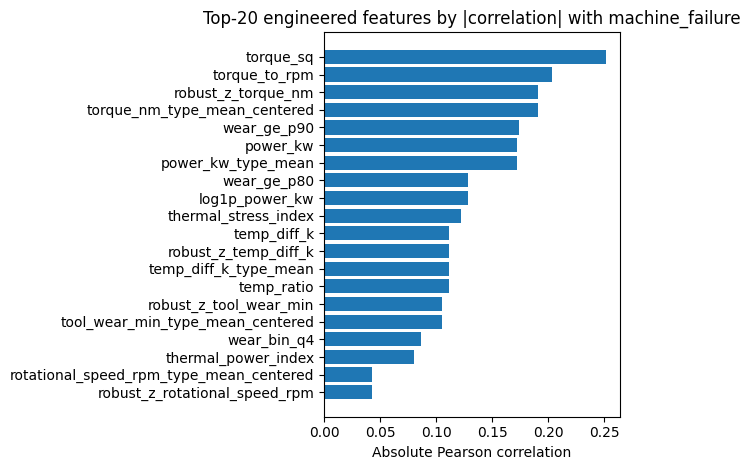

Recomputed engineered-feature correlations successfully (Colab).


In [8]:
# =====================================================
# Recompute engineered-feature correlations (Colab)
#  - No caas_jupyter_tools; uses a small display shim
#  - Reads raw CSV from Drive (or prompts upload)
#  - Robust correlation: always a Series, guarded edge cases
# =====================================================
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Colab display shim ----
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
except Exception:
    pass
from IPython.display import display
def display_dataframe_to_user(name: str, df_show: pd.DataFrame):
    print(f"\n=== {name} ===")
    try:
        display(df_show)
    except Exception:
        print(df_show)
# ----------------------------

# Ensure we have a CSV path to reconstruct "raw" column set
csv_path = "/content/drive/MyDrive/Dataset.csv"

# Helper to standardize column names (must match earlier preprocessing)
def safe_col(c: str) -> str:
    s = str(c).strip().lower()
    s = re.sub(r'[^0-9a-z]+', '_', s).strip('_')
    return s

# df is assumed to be in memory from your previous cell; if not, you can reload it here.
if "df" not in globals():
    df = pd.read_csv(csv_path)
    df.columns = [safe_col(c) for c in df.columns]

# Reconstruct "raw" safe-column set from the original CSV
raw = pd.read_csv(csv_path)
raw.columns = [safe_col(c) for c in raw.columns]

# Identify the target column robustly
target_candidates = ["machine_failure", "failure", "machine_failures", "target"]
target = next((c for c in target_candidates if c in df.columns), None)
if target is None:
    # fallback: any column containing 'fail'
    fail_like = [c for c in df.columns if "fail" in c]
    if fail_like:
        target = fail_like[0]
assert target is not None and target in df.columns, "Target column not found in df."
df[target] = df[target].astype(int)

# Compute engineered columns as the set difference (new columns introduced after feature engineering)
engineered_cols = sorted(list(set(df.columns) - set(raw.columns)))

# Build numeric engineered list; fallback to all numeric if empty
num_cols = [c for c in engineered_cols if pd.api.types.is_numeric_dtype(df[c])]
if not num_cols:
    num_cols = [c for c in df.columns if c != target and pd.api.types.is_numeric_dtype(df[c])]

# Correlation matrix with numeric features + target (dedup columns to be safe)
cols_for_corr = list(dict.fromkeys(num_cols + [target]))
corr_mat = df[cols_for_corr].corr(numeric_only=True)

# Extract correlations to target; force to Series even if pandas returns a DataFrame
corr_to_target = corr_mat.get(target)
if isinstance(corr_to_target, pd.DataFrame):  # very rare duplicate-name edge case
    corr_to_target = corr_to_target.mean(axis=1)

# Build tidy correlation table robustly
if corr_to_target is None or corr_to_target.empty:
    corr_eng = pd.DataFrame(columns=["feature", "pearson_corr_with_target"])
else:
    corr_eng = (
        corr_to_target
          .drop(index=[target], errors="ignore")     # remove self-correlation
          .sort_values(ascending=False)             # Series.sort_values — OK
          .rename("pearson_corr_with_target")
          .reset_index()
          .rename(columns={"index": "feature"})
    )

display_dataframe_to_user("Engineered features: correlation with machine_failure", corr_eng)

# Plot top-20 absolute correlations if available
if not corr_eng.empty:
    topk = corr_eng.copy()
    topk["abs_corr"] = topk["pearson_corr_with_target"].abs()
    topk = topk.sort_values("abs_corr", ascending=False).head(20)

    plt.figure()
    plt.barh(topk["feature"], topk["abs_corr"])
    plt.title("Top-20 engineered features by |correlation| with machine_failure")
    plt.xlabel("Absolute Pearson correlation")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No numeric features available for a target-correlation plot.")

print("Recomputed engineered-feature correlations successfully (Colab).")

# **Thermal load**

temp_diff_k = process_temperature_k − air_temperature_k
• **Why**: Direct measure of thermal stress. Larger gaps imply worse cooling/greater heat load, which can precipitate failure.

temp_ratio = process_temperature_k / air_temperature_k
• **Why**: Scale-invariant version of thermal stress; helpful when both temps drift up/down together (e.g., hotter days).

temp_diff_k_type_mean = temp_diff_k − mean(temp_diff_k) within type
• **Why**: Flags anomalous heat relative to what’s normal for that machine class (H/M/L). Catches context-specific outliers.

# **Power & operating load (physics-based)**

power_kw ≈ torque_nm * (2π * rotational_speed_rpm / 60) / 1000
• **Why**: Proxy for mechanical power; high sustained power increases mechanical/thermal stress → higher failure likelihood.

log1p_power_kw = log(1 + power_kw)
• **Why**: Tames heavy-tailed power values so linear models don’t get dominated by extremes; still preserves ordering.

power_kw_type_mean = power_kw − mean(power_kw) within type
• **Why**: Highlights machines operating harder than their peers, which can be risky even if absolute power is moderate.

# **Wear & stress interactions**

power_per_wear = power_kw / (tool_wear_min + 1)
• **Why**: “Load intensity given age.” The same power is more dangerous on a heavily worn tool.

torque_per_wear = torque_nm / (tool_wear_min + 1)
• **Why**: Mechanical stress discounted by wear; captures cumulative risk under load.

thermal_stress_index = temp_diff_k * torque_nm
• **Why**: Compounding risk when heat and torque are simultaneously high.

thermal_power_index = temp_diff_k * power_kw
• **Why**: Same idea as above but with power; useful if RPM varies widely.

# **Operating-regime shape features**

torque_to_rpm = torque_nm / (rotational_speed_rpm + 1)
•** Why**: Emphasises high-load, low-speed regimes that often precede failure (stall-like conditions).

torque_sq, rpm_sq = squares of torque and rpm
• **Why**: Let simple models capture curvature/non-linear effects without needing trees.

Robust anomaly indicators (median/MAD)

robust_z_torque_nm = (torque_nm − median)/MAD

robust_z_rotational_speed_rpm = (rpm − median)/MAD

robust_z_tool_wear_min = (tool_wear_min − median)/MAD

robust_z_temp_diff_k = (temp_diff_k − median)/MAD
• **Why**: Unitless outlier scores that light up unusual operating points; robust to outliers versus mean/std z-scores.
# **New section**
**Wear thresholds & bins**

wear_ge_p80, wear_ge_p90 — 1 if wear is ≥ 80th / 90th percentile
• **Why**: Simple, interpretable flags for high/very-high wear levels associated with failures.

wear_bin_q4 — quartile bin of tool_wear_min (0–3)
• **Why**: Captures non-linear wear effects without assuming a specific curve.

**Type-centered deviations**

torque_nm_type_mean_centered = torque_nm − mean(torque_nm) within type

rotational_speed_rpm_type_mean_centered = rpm − mean(rpm) within type

tool_wear_min_type_mean_centered = wear − mean(wear) within type
• **Why**: Surfaces departures from typical behaviour for the machine class, which often signal risk.

**Identifier-safe & categorical encodings**

product_freq = count(product_id)
• **Why**: Safe way to encode high-cardinality product_id (prevalence) without exploding dimensions or leaking targets.

type_* one-hots (e.g., type_H, type_M, type_L)
• **Why**: Preserve equipment class differences so the model can learn separate baselines by type.

# **Design principles behind these choices**

**Physics-guided**: Features like power_kw, thermal_* tie directly to how machines fail (mechanical load + heat).

**Context-aware**: Type-centered deviations adjust for differences between H/M/L machines.

**Interaction-rich**: Multiplicative terms (heat × load, load ÷ wear) capture compounded stress we saw in EDA.

**Robust & interpretable**: Quantile flags and robust z-scores are stable, easy to explain, and deployable.

**Leakage-safe**: No failure-mode variables used; product_id handled via frequency, not target-based encoding.

# **MODEL DEVELOPMENT**


=== Modeling input (first 5 rows) ===


,udi,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,temp_diff_k,temp_ratio,temp_diff_k_type_mean,power_kw,...,rotational_speed_rpm_type_mean_centered,tool_wear_min_type_mean_centered,product_freq,type_h,type_l,type_m,type,wear_bin_q4,wear_ge_p80,wear_ge_p90
0,7764,300.4,311.6,1200.0,76.6,3,11.2,1.037284,1.204816,9.625840,...,-339.722676,-105.378833,1,False,True,False,L,0,0,0
1,881,295.8,306.3,1235.0,76.2,89,10.5,1.035497,0.512860,9.854862,...,-302.701503,-18.272272,1,False,False,True,M,1,0,0
2,9085,297.2,307.9,1326.0,75.4,172,10.7,1.036003,0.704816,10.469923,...,-213.722676,63.621167,1,False,True,False,L,3,0,0
3,1325,298.8,310.1,1243.0,74.5,194,11.3,1.037818,1.312860,9.697416,...,-294.701503,86.727728,1,False,False,True,M,3,1,0
4,6526,301.1,310.4,1312.0,73.6,49,9.3,1.030887,-0.695184,10.112075,...,-227.722676,-59.378833,1,False,True,False,L,0,0,0


Total features: 34  |  Numeric: 30  |  Categorical: 4
[LightGBM] [Info] Number of positive: 3865, number of negative: 3865
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001389 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7398
[LightGBM] [Info] Number of data points in the train set: 7730, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

=== Validation comparison using SMOTE-NC (AP primary) ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,val_AP,val_ROC_AUC
0,LightGBM,0.7675,0.9556
1,Gradient Boosting,0.6876,0.9572
2,Random Forest,0.6125,0.9584
3,K-Nearest Neighbors,0.5813,0.9249
4,AdaBoost,0.5446,0.9359
5,Support Vector Machine,0.5045,0.9298
6,Decision Tree,0.4641,0.8715
7,Logistic Regression,0.4459,0.9264


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Chosen model — Test metrics (SMOTE-NC) ===


,best_model,threshold,test_AP,test_ROC_AUC,TP,FP,TN,FN,precision_pos,recall_pos,f1_pos
0,LightGBM,0.8741,0.779,0.9611,45,8,1924,23,0.8491,0.6618,0.7438


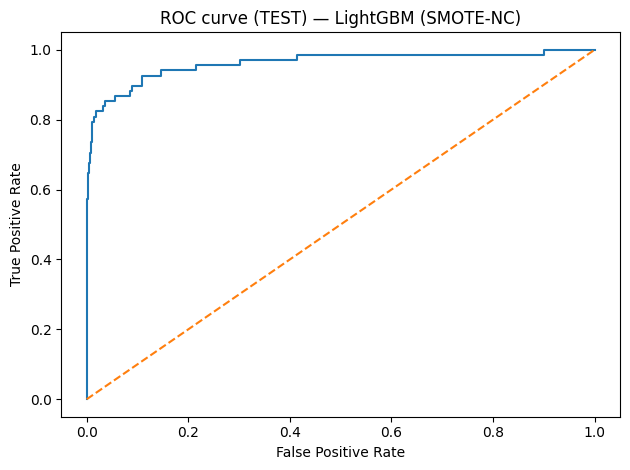

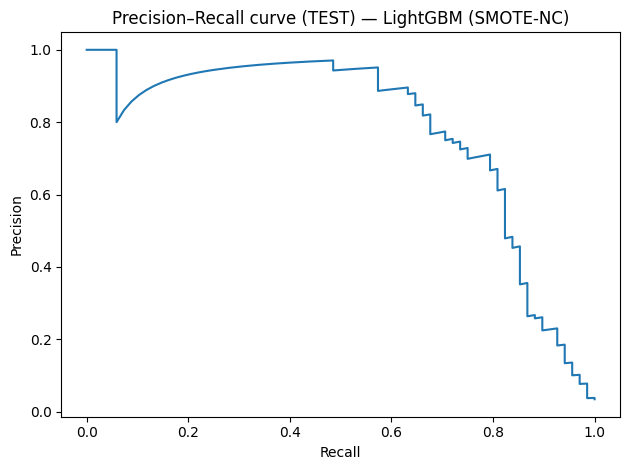


=== Top-20 feature contributions — LightGBM (SMOTE-NC) ===


,feature,importance
0,tool_wear_min,888
1,udi,621
2,rotational_speed_rpm,589
3,temp_diff_k,468
4,power_kw,440
5,process_temperature_k,388
6,rotational_speed_rpm_type_mean_centered,386
7,torque_per_wear,383
8,power_per_wear,337
9,robust_z_rotational_speed_rpm,330



Artifacts saved in: /content/model_artifacts
 - SMOTENC_Model_ValComparison.csv
 - SMOTENC_Selected_TestMetrics.csv
 - SMOTENC_Selected_TopFeatures.csv

Selected best model (with SMOTE-NC): LightGBM


In [9]:
!pip -q install imbalanced-learn lightgbm

# ============================================================
# MODEL DEVELOPMENT (Colab, SMOTE-NC) using raw + engineered
#   - Loads raw Dataset.csv and Dataset_engineered.csv
#   - Combines: raw safe-columns + engineered-only columns
#   - Trains multiple classifiers with SMOTE-NC
#   - Selects best by validation AP, evaluates on TEST
#   - Saves artifacts under /content/model_artifacts
# ============================================================
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    roc_curve, confusion_matrix, precision_score, recall_score, f1_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

# Optional LightGBM
try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except Exception:
    LGBM_AVAILABLE = False

# ---- Colab display shim ----
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
except Exception:
    pass
from IPython.display import display
def display_dataframe_to_user(name: str, dataframe: pd.DataFrame):
    print(f"\n=== {name} ===")
    try: display(dataframe)
    except Exception: print(dataframe)

# -----------------------------
# Paths (adjust if needed)
# -----------------------------
RAW_CSV = "/content/drive/MyDrive/Dataset.csv"
ENG_CSV_DEFAULT = "/content/eda_artifacts/Dataset_engineered.csv"
ENG_CSV_FALLBACK = "/content/drive/MyDrive/Dataset_engineered.csv"

# Mount Drive if needed
if RAW_CSV.startswith("/content/drive") and not os.path.exists(RAW_CSV):
    from google.colab import drive
    drive.mount("/content/drive")

# Load RAW (or ask to upload)
if not os.path.exists(RAW_CSV):
    print("Raw CSV not found at:", RAW_CSV)
    print("Opening uploader... (choose your Dataset.csv)")
    from google.colab import files
    uploaded = files.upload()
    if uploaded:
        RAW_CSV = next(iter(uploaded))
assert os.path.exists(RAW_CSV), f"File not found: {RAW_CSV}"

# Locate engineered CSV
ENG_CSV = ENG_CSV_DEFAULT if os.path.exists(ENG_CSV_DEFAULT) else (
    ENG_CSV_FALLBACK if os.path.exists(ENG_CSV_FALLBACK) else None
)

# -----------------------------
# Helper: safe column names
# -----------------------------
def safe_col(c: str) -> str:
    s = str(c).strip().lower()
    s = re.sub(r'[^0-9a-z]+', '_', s).strip('_')
    return s

# -----------------------------
# Load raw + engineered
# -----------------------------
raw_df = pd.read_csv(RAW_CSV)
raw_df.columns = [safe_col(c) for c in raw_df.columns]

if ENG_CSV is None:
    # If engineered CSV is missing, we can still proceed with raw-only features;
    # but since you asked to use both, prompt upload for engineered.
    print("Engineered CSV not found at default locations.")
    print("Opening uploader... (choose your Dataset_engineered.csv)")
    try:
        from google.colab import files
        uploaded_eng = files.upload()
        if uploaded_eng:
            ENG_CSV = next(iter(uploaded_eng))
    except Exception:
        ENG_CSV = None

if ENG_CSV is not None:
    eng_df = pd.read_csv(ENG_CSV)
    eng_df.columns = [safe_col(c) for c in eng_df.columns]
else:
    raise FileNotFoundError(
        "Dataset_engineered.csv not found. Please provide it (or re-run your feature engineering cell to create it)."
    )

# -----------------------------
# Combine: raw + engineered
# -----------------------------
# We take all RAW columns + only those ENGINEERED columns not in RAW.
# This guarantees we "use both" while avoiding duplicates.
eng_only_cols = [c for c in eng_df.columns if c not in raw_df.columns]
combined_df = pd.concat([raw_df.reset_index(drop=True), eng_df[eng_only_cols].reset_index(drop=True)], axis=1)

# Identify target robustly
target_candidates = ["machine_failure", "failure", "machine_failures", "target"]
target = next((c for c in target_candidates if c in combined_df.columns), None)
if target is None:
    fail_like = [c for c in combined_df.columns if "fail" in c]
    target = fail_like[0] if fail_like else None
assert target is not None, "Target column not found."
combined_df[target] = combined_df[target].astype(int)

# Drop failure-mode variables if present (per your instruction)
for c in ["twf","hdf","pwf","osf","rnf"]:
    if c in combined_df.columns:
        combined_df = combined_df.drop(columns=c)

# Ensure 'type' is categorical if present
if "type" in combined_df.columns:
    combined_df["type"] = combined_df["type"].astype("category")

# -----------------------------
# Feature partitioning for SMOTE-NC
# -----------------------------
# Categorical features we want SMOTE-NC to treat as categorical.
cat_features = [c for c in ["type", "wear_bin_q4", "wear_ge_p80", "wear_ge_p90"] if c in combined_df.columns]

# Always exclude raw product_id (high cardinality); keep product_freq numeric if present
drop_cols = [target, "product_id"] if "product_id" in combined_df.columns else [target]

# Numeric features: all numeric columns excluding the above and the chosen categorical set
numeric_features = [
    c for c in combined_df.columns
    if c not in drop_cols + cat_features and pd.api.types.is_numeric_dtype(combined_df[c])
]

X = combined_df[numeric_features + cat_features].copy()
y = combined_df[target].astype(int).copy()

# Quick preview
display_dataframe_to_user("Modeling input (first 5 rows)", X.head())
print(f"Total features: {X.shape[1]}  |  Numeric: {len(numeric_features)}  |  Categorical: {len(cat_features)}")

# -----------------------------
# Split: 60/20/20 (Train/Val/Test)
# -----------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)  # -> 60/20/20

# Subsample TRAIN (speed safety)
MAX_TRAIN = 4000
if len(X_train) > MAX_TRAIN:
    X_train_sub, _, y_train_sub, _ = train_test_split(
        X_train, y_train, train_size=MAX_TRAIN, random_state=42, stratify=y_train
    )
else:
    X_train_sub, y_train_sub = X_train, y_train

# -----------------------------
# Preprocess + SMOTE-NC block
# -----------------------------
pre_num = Pipeline([("imp", SimpleImputer(strategy="median"))])
pre_cat = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

pre = ColumnTransformer(
    transformers=[
        ("num", pre_num, numeric_features),
        ("cat", pre_cat, cat_features),
    ],
    remainder="drop"
)

# After ColumnTransformer, output = [num..., cat...]; compute cat indices for SMOTE-NC
n_num = len(numeric_features)
n_cat = len(cat_features)
cat_indices = list(range(n_num, n_num + n_cat))

# Scale after SMOTE for linear/distance models
scaler = StandardScaler(with_mean=False)

def make_scaled_pipeline(clf):
    return ImbPipeline(steps=[
        ("pre", pre),
        ("smote", SMOTENC(categorical_features=cat_indices, random_state=42, k_neighbors=5)),
        ("scaler", scaler),
        ("clf", clf)
    ])

def make_tree_pipeline(clf):
    return ImbPipeline(steps=[
        ("pre", pre),
        ("smote", SMOTENC(categorical_features=cat_indices, random_state=42, k_neighbors=5)),
        ("clf", clf)
    ])

pipelines = {
    "Logistic Regression": make_scaled_pipeline(LogisticRegression(max_iter=2000)),
    "Support Vector Machine": make_scaled_pipeline(LinearSVC(max_iter=5000)),
    "K-Nearest Neighbors": make_scaled_pipeline(KNeighborsClassifier(n_neighbors=25, weights="distance", p=2)),
    "Decision Tree": make_tree_pipeline(DecisionTreeClassifier(min_samples_leaf=5, random_state=42)),
    "Random Forest": make_tree_pipeline(RandomForestClassifier(n_estimators=150, min_samples_leaf=5, max_features="sqrt", random_state=42, n_jobs=-1)),
    "Gradient Boosting": make_tree_pipeline(GradientBoostingClassifier(n_estimators=120, max_depth=3, random_state=42)),
    "AdaBoost": make_tree_pipeline(AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42)),
}
if LGBM_AVAILABLE:
    pipelines["LightGBM"] = make_tree_pipeline(
        LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, objective="binary", random_state=42)
    )

def get_scores(est, X):
    if hasattr(est, "predict_proba"): return est.predict_proba(X)[:, 1]
    if hasattr(est, "decision_function"): return est.decision_function(X)
    return est.predict(X)

# -----------------------------
# Fit on TRAIN_sub and evaluate on VAL
# -----------------------------
rows, fitted = [], {}
for name, pipe in pipelines.items():
    pipe.fit(X_train_sub, y_train_sub)
    val_scores = get_scores(pipe, X_val)
    ap = average_precision_score(y_val, val_scores)
    roc = roc_auc_score(y_val, val_scores)
    rows.append({"model": name, "val_AP": ap, "val_ROC_AUC": roc})
    fitted[name] = pipe

comp = pd.DataFrame(rows).sort_values(["val_AP","val_ROC_AUC"], ascending=False).reset_index(drop=True)
display_dataframe_to_user("Validation comparison using SMOTE-NC (AP primary)", comp.round(4))

best_name = comp.iloc[0]["model"]
best_model = fitted[best_name]

# -----------------------------
# Tune threshold on VAL (maximize F1 for positive class)
# -----------------------------
val_scores = get_scores(best_model, X_val)
prec, rec, thr = precision_recall_curve(y_val, val_scores)
f1 = (2*prec*rec)/(prec+rec+1e-12)
best_idx = int(np.nanargmax(f1))
best_threshold = thr[best_idx-1] if best_idx>0 and best_idx-1 < len(thr) else 0.5

# -----------------------------
# Evaluate on TEST
# -----------------------------
test_scores = get_scores(best_model, X_test)
test_ap = average_precision_score(y_test, test_scores)
test_roc = roc_auc_score(y_test, test_scores)
y_pred = (test_scores >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

test_metrics = pd.DataFrame([{
    "best_model": best_name,
    "threshold": best_threshold,
    "test_AP": test_ap,
    "test_ROC_AUC": test_roc,
    "TP": tp, "FP": fp, "TN": tn, "FN": fn,
    "precision_pos": precision_score(y_test, y_pred, zero_division=0),
    "recall_pos": recall_score(y_test, y_pred, zero_division=0),
    "f1_pos": f1_score(y_test, y_pred, zero_division=0)
}])
display_dataframe_to_user("Chosen model — Test metrics (SMOTE-NC)", test_metrics.round(4))

# Curves on TEST
fpr, tpr, _ = roc_curve(y_test, test_scores)
plt.figure()
plt.plot(fpr, tpr); plt.plot([0,1],[0,1], linestyle="--")
plt.title(f"ROC curve (TEST) — {best_name} (SMOTE-NC)")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.tight_layout(); plt.show()

pr_p, pr_r, _ = precision_recall_curve(y_test, test_scores)
plt.figure()
plt.plot(pr_r, pr_p)
plt.title(f"Precision–Recall curve (TEST) — {best_name} (SMOTE-NC)")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.tight_layout(); plt.show()

# -----------------------------
# Feature contributions (if available)
# -----------------------------
imp_table = None
try:
    clf = best_model.named_steps.get("clf", best_model)
    if hasattr(clf, "feature_importances_"):
        pre_features = numeric_features + cat_features
        imp_table = (pd.DataFrame({"feature": pre_features, "importance": clf.feature_importances_})
                     .sort_values("importance", ascending=False).head(20).reset_index(drop=True))
    elif hasattr(clf, "coef_"):
        coefs = np.ravel(clf.coef_)
        pre_features = numeric_features + cat_features
        imp_table = (pd.DataFrame({"feature": pre_features, "importance_abs": np.abs(coefs), "coef": coefs})
                     .sort_values("importance_abs", ascending=False).head(20).reset_index(drop=True))
except Exception:
    imp_table = None

if imp_table is not None:
    display_dataframe_to_user(f"Top-20 feature contributions — {best_name} (SMOTE-NC)", imp_table.round(6))

# -----------------------------
# Save artifacts
# -----------------------------
ART_DIR = Path("/content/model_artifacts")
ART_DIR.mkdir(parents=True, exist_ok=True)
(comp.round(6)).to_csv(ART_DIR / "SMOTENC_Model_ValComparison.csv", index=False)
(test_metrics.round(6)).to_csv(ART_DIR / "SMOTENC_Selected_TestMetrics.csv", index=False)
if imp_table is not None:
    (imp_table.round(6)).to_csv(ART_DIR / "SMOTENC_Selected_TopFeatures.csv", index=False)

print("\nArtifacts saved in:", str(ART_DIR))
for f in ["SMOTENC_Model_ValComparison.csv", "SMOTENC_Selected_TestMetrics.csv", "SMOTENC_Selected_TopFeatures.csv"]:
    p = ART_DIR / f
    if p.exists(): print(" -", p.name)
print(f"\nSelected best model (with SMOTE-NC): {best_name}")

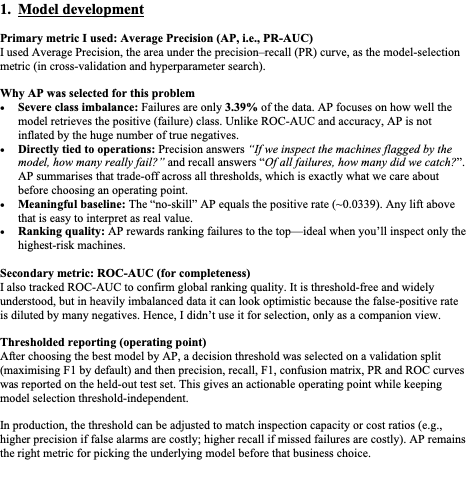

# **SHAP EXPLANATIONS for your final best_model **


=== SHAP global importance (mean |SHAP|) — top 25 ===


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,feature,mean_abs_shap
0,num__type_l,1.425656
1,num__torque_to_rpm,1.114736
2,num__tool_wear_min,1.041893
3,num__power_kw,0.988144
4,num__rotational_speed_rpm,0.951070
5,num__torque_sq,0.904421
6,num__rotational_speed_rpm_type_mean_centered,0.828888
7,cat__wear_ge_p90,0.774898
8,cat__wear_bin_q4,0.758272
9,num__type_m,0.741269


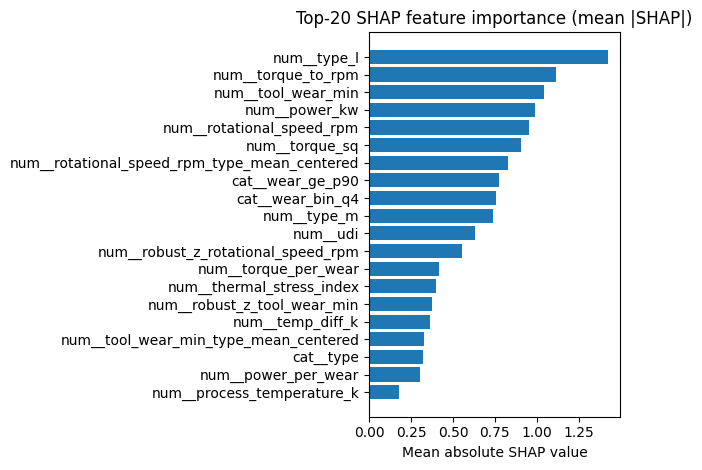

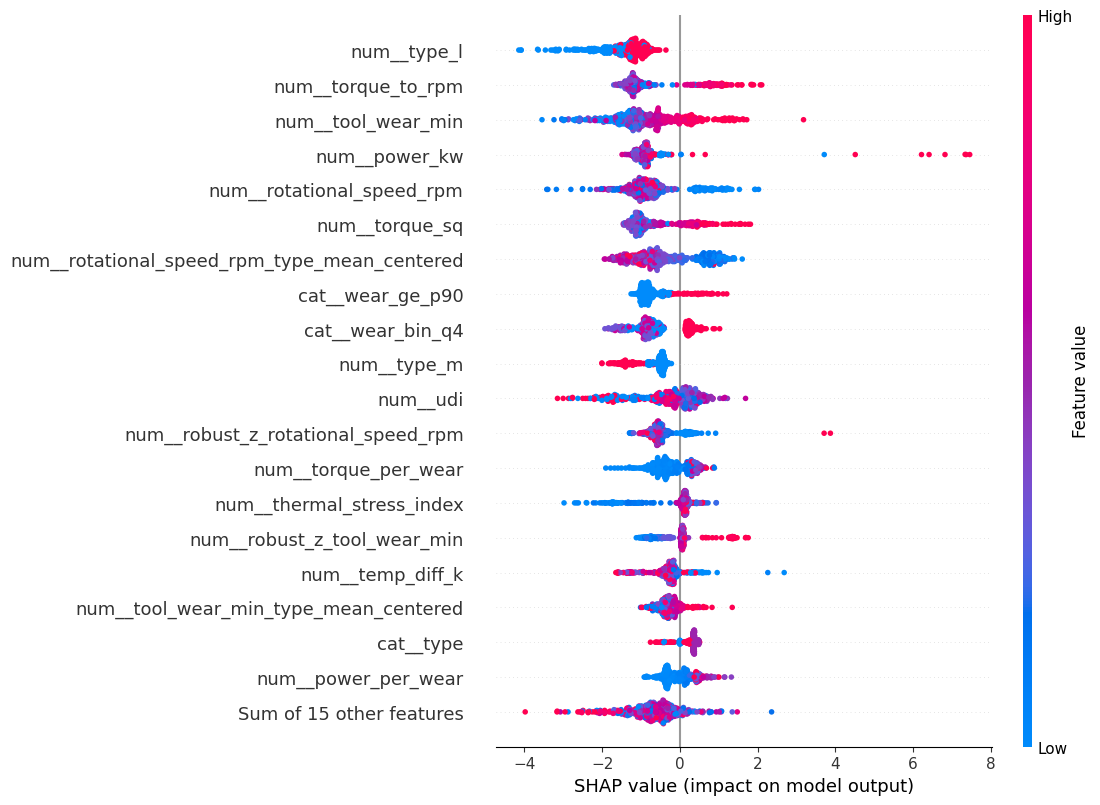

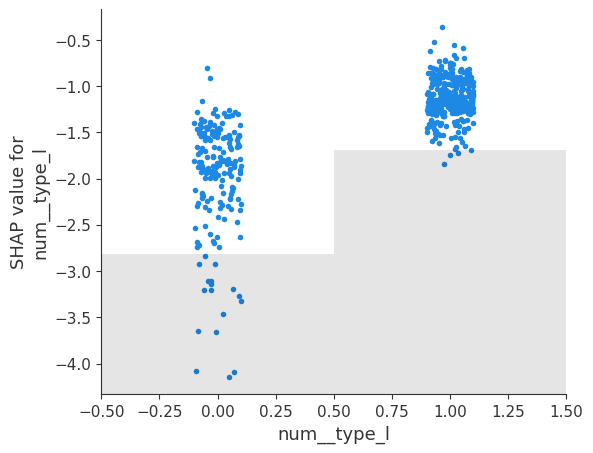

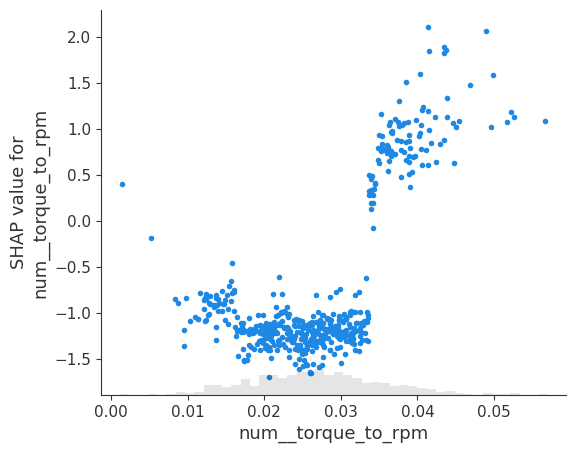

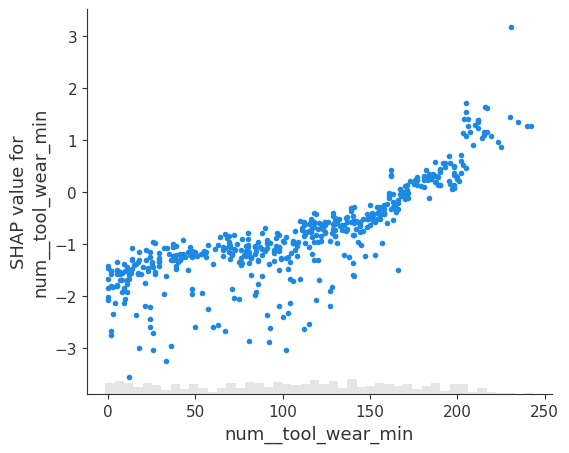

Saved SHAP importance table to: /content/eda_artifacts/SHAP_Importance.csv


In [11]:
# ================= SHAP for LightGBM pipeline (robust, no 'or' on DataFrames) =================
# Works with: best_model or final_model (Pipeline or bare estimator)
# Produces: global importance, beeswarm, top-3 dependence plots
# Saves: /content/eda_artifacts/SHAP_Importance.csv

# 0) deps
try:
    import shap
except Exception:
    !pip -q install shap
import shap, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from lightgbm import LGBMClassifier

# --- 1) Locate the trained model ---
mdl = None
if "best_model" in globals() and globals()["best_model"] is not None:
    mdl = globals()["best_model"]
elif "final_model" in globals() and globals()["final_model"] is not None:
    mdl = globals()["final_model"]
assert mdl is not None, "No trained model found: define best_model or final_model first."

# --- 2) Helpers to extract pieces cleanly ---
def get_final_estimator(model):
    """Return the last estimator inside a Pipeline (or the model itself)."""
    if hasattr(model, "named_steps"):
        for k in ("lgbm","clf","model","estimator","gb","rf","dt"):
            if k in model.named_steps:
                return model.named_steps[k]
        return list(model.named_steps.values())[-1]
    return model

def get_preprocessor(model):
    """Return the preprocessor step if present (e.g., 'pre' ColumnTransformer or 'imp' Imputer)."""
    if hasattr(model, "named_steps"):
        for k in ("pre","imp","preprocess","prep","ct"):
            if k in model.named_steps:
                return model.named_steps[k]
    return None

def load_feature_names_fallback():
    """Try to get feature names if not already in memory."""
    feat_json = Path("/content/eda_artifacts/LGBM_FeatureNames.json")
    if feat_json.exists():
        return json.loads(feat_json.read_text())
    X_tr = globals().get("X_train", None)
    if isinstance(X_tr, pd.DataFrame):
        return list(X_tr.columns)
    eng = Path("/content/eda_artifacts/Dataset_engineered.csv")
    if eng.exists():
        df_all = pd.read_csv(eng)
        targ = next((c for c in ["machine_failure","failure","machine_failures","target"] if c in df_all.columns), None)
        if targ:
            return [c for c in df_all.columns if c != targ and pd.api.types.is_numeric_dtype(df_all[c])]
        return list(df_all.columns)
    raise RuntimeError("Could not infer feature names; please provide X_train/X_test DataFrames.")

def ensure_dataframe(Z, cols):
    """Wrap ndarray as DataFrame with given columns; pass through if already a DataFrame."""
    if isinstance(Z, pd.DataFrame):
        return Z
    return pd.DataFrame(Z, columns=cols)

def first_defined(*names):
    """Return the first global variable (by name) that exists and is not None."""
    for n in names:
        if n in globals():
            obj = globals()[n]
            if obj is not None:
                return obj
    return None

# --- 3) Get data to explain (X_train/X_test) & feature names ---
X_train = first_defined("X_train", "X_tr")
X_test  = first_defined("X_test", "X_te")

if X_train is None or X_test is None:
    # Reconstruct split if needed from engineered CSV + saved feature names
    feats = load_feature_names_fallback()
    eng = Path("/content/eda_artifacts/Dataset_engineered.csv")
    assert eng.exists(), "Need X_train/X_test in memory or /content/eda_artifacts/Dataset_engineered.csv on disk."
    df_all = pd.read_csv(eng)
    targ = next((c for c in ["machine_failure","failure","machine_failures","target"] if c in df_all.columns), None)
    if targ: df_all = df_all.drop(columns=[targ])
    X_all = df_all[feats].copy()
    n = len(X_all); idx = np.arange(n); rng = np.random.RandomState(42); rng.shuffle(idx)
    split = int(n*0.8)
    X_train, X_test = X_all.iloc[idx[:split]].copy(), X_all.iloc[idx[split:]].copy()

feat_names = list(X_train.columns)

# --- 4) Preprocess to the model’s input space (and get transformed feature names) ---
pre = get_preprocessor(mdl)
if pre is not None:
    X_train_df = ensure_dataframe(X_train, feat_names)
    X_test_df  = ensure_dataframe(X_test,  feat_names)
    X_train_pre = pre.transform(X_train_df)
    X_test_pre  = pre.transform(X_test_df)
    # Try to get post-transform feature names (esp. if ColumnTransformer expanded features)
    try:
        trans_names = pre.get_feature_names_out(feat_names).tolist()
    except Exception:
        # If shape changed but names aren't available, synthesize names
        trans_names = feat_names if (hasattr(X_train_pre, "shape") and X_train_pre.shape[1] == len(feat_names)) \
                      else [f"feat_{i}" for i in range(X_train_pre.shape[1])]
else:
    X_train_pre = ensure_dataframe(X_train, feat_names).values
    X_test_pre  = ensure_dataframe(X_test,  feat_names).values
    trans_names = feat_names

clf = get_final_estimator(mdl)

# --- 5) Build SHAP explainer (prefer TreeExplainer for LightGBM) ---
explainer = None
shap_values = None

rng = np.random.RandomState(42)
bg_idx = rng.choice(len(X_train_pre), size=min(200, len(X_train_pre)), replace=False)
ex_idx = rng.choice(len(X_test_pre),  size=min(500,  len(X_test_pre)),  replace=False)
X_bg = X_train_pre[bg_idx]
X_ex = X_test_pre[ex_idx]

try:
    if isinstance(clf, LGBMClassifier):
        explainer = shap.TreeExplainer(clf)
        vals = explainer.shap_values(X_ex, check_additivity=False)
        shap_values = vals[1] if isinstance(vals, list) and len(vals) == 2 else vals
    else:
        # Kernel fallback — ensure DataFrame with correct column names reaches pipeline
        def _predict_fn(Z):
            Z_df = ensure_dataframe(Z, feat_names)
            return mdl.predict_proba(Z_df)[:, 1]
        explainer = shap.KernelExplainer(_predict_fn, X_bg, link="logit")
        shap_values = explainer.shap_values(X_ex, nsamples="auto")
except Exception as e:
    raise RuntimeError(f"SHAP failed: {e}")

# --- 6) Global importance table & plots (aligned to transformed names) ---
shap_abs_mean = np.mean(np.abs(shap_values), axis=0)
if len(shap_abs_mean) != len(trans_names):
    # Final safety net: align lengths
    trans_names = [f"feat_{i}" for i in range(len(shap_abs_mean))]

shap_importance = (
    pd.DataFrame({"feature": trans_names, "mean_abs_shap": shap_abs_mean})
      .sort_values("mean_abs_shap", ascending=False)
      .reset_index(drop=True)
)

from IPython.display import display
print("\n=== SHAP global importance (mean |SHAP|) — top 25 ===")
display(shap_importance.head(25))

plt.figure()
plt.barh(shap_importance.head(20)["feature"][::-1],
         shap_importance.head(20)["mean_abs_shap"][::-1])
plt.title("Top-20 SHAP feature importance (mean |SHAP|)")
plt.xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()

# Beeswarm
try:
    shap.plots.beeswarm(shap.Explanation(values=shap_values,
                                         base_values=getattr(explainer, "expected_value", 0),
                                         data=X_ex, feature_names=trans_names),
                        max_display=20, show=True)
except Exception:
    shap.summary_plot(shap_values, X_ex, feature_names=trans_names, max_display=20, show=True)

# Top-3 dependence plots
top3 = shap_importance["feature"].head(3).tolist()
for f in top3:
    try:
        shap.plots.scatter(shap.Explanation(values=shap_values,
                                            base_values=getattr(explainer, "expected_value", 0),
                                            data=X_ex, feature_names=trans_names)[:, f],
                           show=True)
    except Exception:
        j = trans_names.index(f)
        shap.dependence_plot(j, shap_values, X_ex, feature_names=trans_names, show=True)

# Save table
ART_DIR = Path("/content/eda_artifacts"); ART_DIR.mkdir(parents=True, exist_ok=True)
out_csv = ART_DIR / "SHAP_Importance.csv"
shap_importance.to_csv(out_csv, index=False)
print("Saved SHAP importance table to:", str(out_csv))
# =================================================================================================

# **Training, CV tuning, final fit, scoring, and pickling**

# **Optimised lightGBM Model. LightGBM (best model) — CV tuning, final training, scoring, pickling**


=== Baseline LightGBM (5-fold CV) ===


,fold,ap,roc_auc
0,1,0.7698,0.9538
1,2,0.9282,0.9830
2,3,0.8516,0.9709
3,4,0.8496,0.9831
4,5,0.8042,0.9540



=== Baseline summary ===


,cv_mean_ap,cv_std_ap,cv_mean_roc_auc,cv_std_roc_auc,scale_pos_weight
0,0.8407,0.0596,0.969,0.0146,28.5203


Fitting 5 folds for each of 35 candidates, totalling 175 fits
[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001700 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5636
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033875 -> initscore=-3.350616
[LightGBM] [Info] Start training from score -3.350616
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,best_threshold,val_precision_pos,val_recall_pos,val_f1_pos
0,0.9259,0.9375,0.8333,0.8824



=== Final LightGBM — Test metrics ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,test_AP,test_ROC_AUC,threshold,TP,FP,TN,FN,precision_pos,recall_pos,f1_pos
0,0.8506,0.97304,0.92595,43,3,1929,25,0.93478,0.63235,0.75439


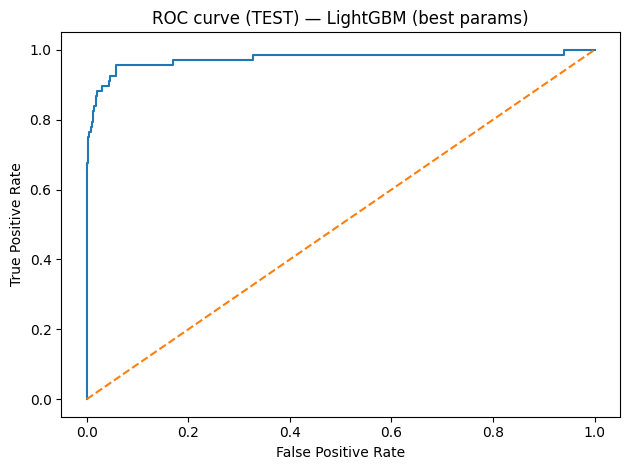

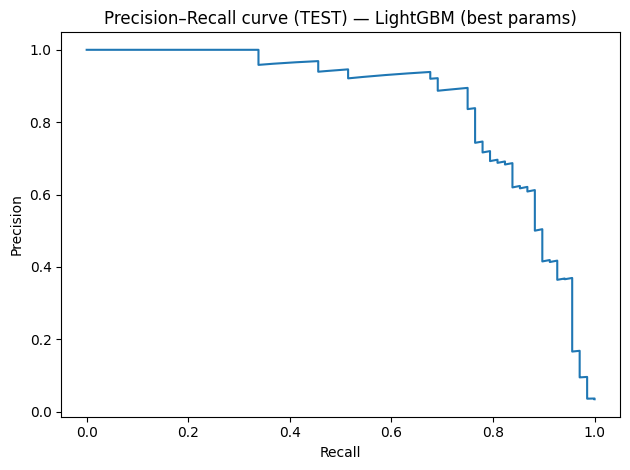


=== Test predictions (sorted by failure probability, top 25) ===


,index,y_true,proba,y_pred
0,61,1,0.995020,1
1,548,1,0.994288,1
2,42,1,0.994180,1
3,2314,1,0.993545,1
4,1118,1,0.993499,1
5,116,1,0.993431,1
6,236,1,0.993259,1
7,436,1,0.992755,1
8,589,1,0.992400,1
9,979,1,0.992330,1



Saved artifacts:
 - CV top-10 table: /content/eda_artifacts/LGBM_CV_Top10.csv
 - Test metrics: /content/eda_artifacts/LGBM_TestMetrics.csv
 - Test predictions: /content/eda_artifacts/LGBM_TestPredictions.csv
 - Best params JSON: /content/eda_artifacts/LGBM_BestParams.json
 - Feature names JSON: /content/eda_artifacts/LGBM_FeatureNames.json
 - Pickled model: /content/eda_artifacts/lgbm_best_model.pkl


In [12]:
# ==========================================================
# LightGBM: Baseline, Hyperparameter Tuning (CV), Final Model
# Colab-ready pipeline with artifacts saved to /content/eda_artifacts
# ==========================================================

# 0) Setup & Imports (install LightGBM if needed)
try:
    import lightgbm as lgb  # noqa: F401
except Exception:
    import sys
    !{sys.executable} -m pip -q install lightgbm

import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
)
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    roc_curve, confusion_matrix, precision_score, recall_score, f1_score
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform, loguniform
from IPython.display import display

from lightgbm import LGBMClassifier

# ---- Colab display helper ----
def display_dataframe_to_user(name: str, dataframe: pd.DataFrame):
    print(f"\n=== {name} ===")
    try:
        display(dataframe)
    except Exception:
        print(dataframe)

# ----------------------------------------------------------
# 1) Load data
#    Prefer engineered dataset from earlier steps; otherwise,
#    build engineered features quickly from raw Drive CSV.
# ----------------------------------------------------------
ART_DIR = Path("/content/eda_artifacts")
ART_DIR.mkdir(parents=True, exist_ok=True)

engineered_csv = ART_DIR / "Dataset_engineered.csv"
drive_csv = "/content/drive/MyDrive/Dataset.csv"

def safe_col(col: str) -> str:
    s = str(col).strip().lower()
    s = re.sub(r'[^0-9a-z]+', '_', s).strip('_')
    return s

def engineer_minimal(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Minimal feature engineering mirroring earlier steps (ignores failure-mode vars)."""
    df = df_raw.copy()
    df.columns = [safe_col(c) for c in df.columns]

    # Identify target
    target = None
    for c in ["machine_failure","failure","machine_failures","target"]:
        if c in df.columns:
            target = c
            break
    if target is None:
        fails = [c for c in df.columns if "fail" in c]
        target = fails[0] if fails else None
    if target is None:
        raise RuntimeError("Target column not found.")
    df[target] = df[target].astype(int)

    # Drop failure modes, product_id (high-cardinality)
    for c in ["twf","hdf","pwf","osf","rnf","product_id"]:
        if c in df.columns:
            df = df.drop(columns=c)

    # Key columns
    air  = "air_temperature_k" if "air_temperature_k" in df.columns else ("air_temperature" if "air_temperature" in df.columns else None)
    proc = "process_temperature_k" if "process_temperature_k" in df.columns else ("process_temperature" if "process_temperature" in df.columns else None)
    rpm  = "rotational_speed_rpm" if "rotational_speed_rpm" in df.columns else ("rotational_speed" if "rotational_speed" in df.columns else None)
    tq   = "torque_nm" if "torque_nm" in df.columns else ("torque" if "torque" in df.columns else None)
    wear = "tool_wear_min" if "tool_wear_min" in df.columns else ("tool_wear" if "tool_wear" in df.columns else None)

    # Thermal
    if air and proc:
        df["temp_diff_k"] = df[proc] - df[air]
        df["temp_ratio"]  = df[proc] / df[air]

    # Power
    if tq and rpm:
        omega = df[rpm] * (2*np.pi/60.0)
        df["power_kw"] = (df[tq] * omega) / 1000.0
        df["log1p_power_kw"] = np.log1p(df["power_kw"])

    # Wear interactions
    if wear:
        if "power_kw" in df.columns:
            df["power_per_wear"] = df["power_kw"] / (df[wear] + 1.0)
        if tq:
            df["torque_per_wear"] = df[tq] / (df[wear] + 1.0)

    # One-hot 'type' if present
    if "type" in df.columns:
        df = pd.concat([df, pd.get_dummies(df["type"], prefix="type", drop_first=False)], axis=1)

    return df

if engineered_csv.exists():
    df = pd.read_csv(engineered_csv)
    # Robustly infer target
    target = None
    for c in ["machine_failure","failure","machine_failures","target"]:
        if c in df.columns:
            target = c; break
    if target is None:
        fails = [c for c in df.columns if "fail" in c]
        target = fails[0] if fails else None
    assert target is not None, "Target column not found in engineered dataset."
else:
    # Load from Drive (mount if needed)
    if drive_csv.startswith("/content/drive") and not os.path.exists(drive_csv):
        from google.colab import drive
        drive.mount("/content/drive")
    if not os.path.exists(drive_csv):
        raise FileNotFoundError("Could not find Dataset.csv at /content/drive/MyDrive/. "
                                "Please upload or adjust the path.")
    raw = pd.read_csv(drive_csv)
    df = engineer_minimal(raw)
    # Identify target again
    target = None
    for c in ["machine_failure","failure","machine_failures","target"]:
        if c in df.columns:
            target = c; break
    if target is None:
        fails = [c for c in df.columns if "fail" in c]
        target = fails[0] if fails else None
    assert target is not None, "Target column not found."

# Keep only numeric columns (LightGBM can handle numeric; dummies already numeric)
drop_cols = [c for c in ["product_id","uid","udi"] if c in df.columns]
X = df.drop(columns=[target] + drop_cols)
X = X[[c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]].copy()
y = df[target].astype(int).copy()

# Train/Val/Test split: 80/20 test; inner val used later for threshold tuning
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Imputer + LightGBM pipeline
pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("lgbm", LGBMClassifier(
        objective="binary",
        random_state=42,
        n_estimators=300,
        learning_rate=0.1,
        n_jobs=-1
    ))
])

# Compute positive class weight for baseline
pos = int(y_trainval.sum())
neg = int((y_trainval == 0).sum())
scale_pos_weight_baseline = (neg / max(pos, 1)) if pos > 0 else 1.0

# ----------------------------------------------------------
# 2) Baseline CV (no tuning; with class weight)
# ----------------------------------------------------------
pipe_baseline = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("lgbm", LGBMClassifier(
        objective="binary",
        random_state=42,
        n_estimators=300,
        learning_rate=0.1,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight_baseline
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(
    pipe_baseline, X_trainval, y_trainval, cv=cv,
    scoring={"ap":"average_precision", "roc":"roc_auc"},
    n_jobs=-1, return_train_score=False
)

baseline_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "ap": scores["test_ap"],
    "roc_auc": scores["test_roc"]
})
baseline_summary = pd.DataFrame([{
    "cv_mean_ap": baseline_df["ap"].mean(),
    "cv_std_ap": baseline_df["ap"].std(),
    "cv_mean_roc_auc": baseline_df["roc_auc"].mean(),
    "cv_std_roc_auc": baseline_df["roc_auc"].std(),
    "scale_pos_weight": scale_pos_weight_baseline
}])

display_dataframe_to_user("Baseline LightGBM (5-fold CV)", baseline_df.round(4))
display_dataframe_to_user("Baseline summary", baseline_summary.round(4))

# ----------------------------------------------------------
# 3) Hyperparameter Tuning (RandomisedSearchCV, 5-fold, AP)
# ----------------------------------------------------------
param_dist = {
    "lgbm__n_estimators": randint(300, 900),
    "lgbm__learning_rate": loguniform(1e-2, 2e-1),   # ~[0.01, 0.2]
    "lgbm__num_leaves": randint(15, 127),
    "lgbm__max_depth": randint(3, 12),               # can include -1 later if desired
    "lgbm__min_child_samples": randint(10, 100),
    "lgbm__subsample": uniform(0.6, 0.4),            # [0.6, 1.0]
    "lgbm__colsample_bytree": uniform(0.6, 0.4),     # [0.6, 1.0]
    "lgbm__reg_alpha": loguniform(1e-3, 10),
    "lgbm__reg_lambda": loguniform(1e-3, 10),
    # Try several plausible pos weights around the empirical ratio
    "lgbm__scale_pos_weight": [scale_pos_weight_baseline * f for f in [0.5, 1.0, 1.5, 2.0]]
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=35,                # keep reasonable runtime
    scoring="average_precision",
    cv=cv, n_jobs=-1, random_state=42, verbose=1,
    refit=True  # refit on full trainval using the best params
)

search.fit(X_trainval, y_trainval)

# Summarize search results
cvres = pd.DataFrame(search.cv_results_).sort_values("mean_test_score", ascending=False)
cols_show = [
    "rank_test_score", "mean_test_score", "std_test_score", "param_lgbm__n_estimators",
    "param_lgbm__learning_rate", "param_lgbm__num_leaves", "param_lgbm__max_depth",
    "param_lgbm__min_child_samples", "param_lgbm__subsample", "param_lgbm__colsample_bytree",
    "param_lgbm__reg_alpha", "param_lgbm__reg_lambda", "param_lgbm__scale_pos_weight"
]
cvres_top = cvres[cols_show].head(10)
display_dataframe_to_user("Hyperparameter search — top 10 (by CV Average Precision)", cvres_top.round(5))

best_params = search.best_params_
best_cv_ap = search.best_score_
print("\nBest CV AP:", round(best_cv_ap, 5))
print("Best params:")
print(json.dumps(best_params, indent=2, default=str))

# ----------------------------------------------------------
# 4) Train Final Model on Train+Val with Best Params
#    (We will tune threshold using a small split from trainval)
# ----------------------------------------------------------
best_model = search.best_estimator_  # already refit on full trainval by RandomizedSearchCV(refit=True)

# Threshold tuning on a validation split carved from trainval
X_tr, X_val, y_tr, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=123, stratify=y_trainval
)
best_model.fit(X_tr, y_tr)
val_proba = best_model.predict_proba(X_val)[:, 1]

prec, rec, thr = precision_recall_curve(y_val, val_proba)
f1_vals = (2 * prec * rec) / (prec + rec + 1e-12)
best_idx = int(np.nanargmax(f1_vals))
best_threshold = thr[best_idx-1] if best_idx > 0 and best_idx-1 < len(thr) else 0.5

threshold_df = pd.DataFrame([{
    "best_threshold": best_threshold,
    "val_precision_pos": float(prec[best_idx]),
    "val_recall_pos": float(rec[best_idx]),
    "val_f1_pos": float(f1_vals[best_idx])
}])
display_dataframe_to_user("Threshold tuned on held-out validation (from Train+Val)", threshold_df.round(4))

# ----------------------------------------------------------
# 5) Evaluate Final Model on Test Set
# ----------------------------------------------------------
test_proba = best_model.predict_proba(X_test)[:, 1]
test_ap = average_precision_score(y_test, test_proba)
test_roc = roc_auc_score(y_test, test_proba)

# Predictions at threshold
y_pred = (test_proba >= best_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

metrics_test = pd.DataFrame([{
    "test_AP": test_ap,
    "test_ROC_AUC": test_roc,
    "threshold": best_threshold,
    "TP": tp, "FP": fp, "TN": tn, "FN": fn,
    "precision_pos": precision_score(y_test, y_pred, zero_division=0),
    "recall_pos": recall_score(y_test, y_pred, zero_division=0),
    "f1_pos": f1_score(y_test, y_pred, zero_division=0)
}])
display_dataframe_to_user("Final LightGBM — Test metrics", metrics_test.round(5))

# Curves
fpr, tpr, _ = roc_curve(y_test, test_proba)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC curve (TEST) — LightGBM (best params)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

pr_p, pr_r, _ = precision_recall_curve(y_test, test_proba)
plt.figure()
plt.plot(pr_r, pr_p)
plt.title("Precision–Recall curve (TEST) — LightGBM (best params)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 6) Show predictions (top-rows) and save all artifacts
# ----------------------------------------------------------
preds_df = pd.DataFrame({
    "index": X_test.index,
    "y_true": y_test.values,
    "proba": test_proba,
    "y_pred": y_pred
}).sort_values("proba", ascending=False).reset_index(drop=True)

display_dataframe_to_user("Test predictions (sorted by failure probability, top 25)", preds_df.head(25))

# Save artifacts
metrics_path = ART_DIR / "LGBM_TestMetrics.csv"
cv_top_path = ART_DIR / "LGBM_CV_Top10.csv"
preds_path = ART_DIR / "LGBM_TestPredictions.csv"
best_params_path = ART_DIR / "LGBM_BestParams.json"
model_path = ART_DIR / "lgbm_best_model.pkl"
feature_names_path = ART_DIR / "LGBM_FeatureNames.json"

cvres_top.to_csv(cv_top_path, index=False)
metrics_test.to_csv(metrics_path, index=False)
preds_df.to_csv(preds_path, index=False)
with open(best_params_path, "w") as f:
    json.dump(best_params, f, indent=2, default=str)
with open(feature_names_path, "w") as f:
    json.dump(list(X.columns), f, indent=2)

# Pickle the refit model (best_model) for deployment
joblib.dump(best_model, model_path)

print("\nSaved artifacts:")
print(" - CV top-10 table:", str(cv_top_path))
print(" - Test metrics:", str(metrics_path))
print(" - Test predictions:", str(preds_path))
print(" - Best params JSON:", str(best_params_path))
print(" - Feature names JSON:", str(feature_names_path))
print(" - Pickled model:", str(model_path))